24-12-25_Final Part-3.3A: REGRESSION QSAR (pIC50) — Publication Pipeline (TIFF only, AD + OOF + Williams)
"""
Final Part-3.3A: REGRESSION QSAR (pIC50) — Publication Pipeline

✅ Model selection by CV_RMSE ONLY (no test leakage)
✅ Stratified regression split (pIC50 quantile bins) for robust evaluation
✅ OOF (out-of-fold) train predictions for honest training performance plots
✅ External validation metrics: R²_test, RMSE_test, MAE_test, Q²_test, CCC
✅ Y-scrambling test (sanity check)
✅ Applicability Domain for unknowns: PCA-space kNN distance (fast for 30k)
✅ Williams plot using PCA-leverage (feasible for high-dimensional descriptors)
✅ Publication-quality TIFF figures
✅ Saves: metrics CSV, model bundle PKL, unknown predictions CSV, report TXT, ZIP

Notes:
- SHAP is optional and OFF (it can be slow).
- AD is ON by default but designed to be fast (PCA + kNN + chunking).
"""

In [ ]:
# @title # 1) INSTALL PACKAGES
# =========================
!pip -q install scikit-learn xgboost lightgbm catboost pandas numpy scipy matplotlib joblib umap-learn

import os, zipfile, warnings, datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import (
    StratifiedShuffleSplit, KFold, GridSearchCV, RandomizedSearchCV,
    cross_val_score, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import clone

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import joblib
from google.colab import files
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
# @title # 2) PUBLICATION PLOT SETTINGS (TIFF ONLY)
# =========================
plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.6,
    "xtick.major.width": 1.4,
    "ytick.major.width": 1.4,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.edgecolor": "black",
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
    "patch.linewidth": 1.2,
})

COLORS = {
    "primary":   "#FDB863",  # blue
    "secondary": "#59A14F",  # green
    "accent":    "#F28E2B",  # orange
    "highlight": "#E15759",  # red-orange
    "neutral":   "#9C9C9C",  # gray
    "best":      "#C73E1D",  # strong red
    "train":     "#4E79A7",
    "test":      "#59A14F",
}

def save_tiff(fig, filename_base, outdir, dpi=600):
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, f"{filename_base}.tiff")
    try:
        fig.savefig(
            path, format="tiff", dpi=dpi, bbox_inches="tight",
            pil_kwargs={"compression": "tiff_lzw"},
            facecolor="white", edgecolor="none"
        )
    except TypeError:
        fig.savefig(path, format="tiff", dpi=dpi, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
    print(f"✅ Saved TIFF: {path}")
    return path

In [ ]:
# @title # 3) USER SETTINGS
# =========================
OUTPUT_PREFIX = "GSK3B"     # <-- change per gene (BCL6 / MYC / HIF1A / PPARG)
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5

SCALING = "standard"        # "standard" | "robust" | "minmax"

# Speed controls
RUN_HEAVY_MODELS = True     # SVR/MLP can be slow; keep True only if dataset small enough
USE_RANDOM_SEARCH = True    # faster than full GridSearch for boosters
RANDOM_SEARCH_ITERS = 20

# Validation extras
ENABLE_Y_SCRAMBLING   = True
Y_SCRAMBLE_ITERS      = 25

# Chemical space
ENABLE_PCA_SPACE      = True

# Applicability Domain for UNKNOWN predictions (recommended)
ENABLE_AD_UNKNOWN     = True
AD_PCA_COMPONENTS     = 30   # PCA components used for AD (fast & stable)
AD_KNN_K              = 5
AD_PERCENTILE_THR     = 95   # threshold = 95th percentile train kNN distance
UNK_CHUNK_SIZE        = 5000 # chunking for 30k+

# Optional: fast feature importance (recommended ON)
ENABLE_FEATURE_IMPORTANCE = True
TOP_FEATURES = 25

# Optional: SHAP (slow). Keep OFF unless needed.
ENABLE_SHAP = False

np.random.seed(RANDOM_STATE)
print("🎯 OUTPUT_PREFIX:", OUTPUT_PREFIX)

🎯 OUTPUT_PREFIX: GSK3B


In [ ]:
# @title # 4) UPLOAD FILES
# =========================
print("\n📁 Upload the KNOWN descriptor CSV (Part-3.1) containing pIC50 + descriptors.")
known_up = files.upload()
known_file = list(known_up.keys())[0]
print("✅ Known file:", known_file)

print("\n📁 OPTIONAL: Upload UNKNOWN descriptor CSV (Part-3.2). Cancel if not available.")
try:
    unk_up = files.upload()
    unknown_file = list(unk_up.keys())[0] if len(unk_up.keys()) > 0 else None
except Exception:
    unknown_file = None
print("Unknown file:", unknown_file)


📁 Upload the KNOWN descriptor CSV (Part-3.1) containing pIC50 + descriptors.


Saving GSK3B_RDKit2D_plus_ECFP4_2048.csv to GSK3B_RDKit2D_plus_ECFP4_2048.csv
✅ Known file: GSK3B_RDKit2D_plus_ECFP4_2048.csv

📁 OPTIONAL: Upload UNKNOWN descriptor CSV (Part-3.2). Cancel if not available.


Saving GSK3B_UNKNOWN_COMBINED.csv to GSK3B_UNKNOWN_COMBINED.csv
Unknown file: GSK3B_UNKNOWN_COMBINED.csv


In [ ]:
# @title # 5) OUTPUT FOLDERS
# =========================
OUTROOT   = f"/content/Regression_Prediction_{OUTPUT_PREFIX}"
OUT_DATA  = os.path.join(OUTROOT, "DATA")
OUT_PLOTS = os.path.join(OUTROOT, "PLOTS")
OUT_MODELS= os.path.join(OUTROOT, "MODELS")
OUT_REPORT= os.path.join(OUTROOT, "REPORTS")
for p in [OUTROOT, OUT_DATA, OUT_PLOTS, OUT_MODELS, OUT_REPORT]:
    os.makedirs(p, exist_ok=True)

In [ ]:
# @title # 6) LOAD DATA + FEATURES
# =========================
df = pd.read_csv(known_file)
print("\n📊 Known dataset shape:", df.shape)

if "pIC50" not in df.columns:
    raise ValueError("❌ 'pIC50' column not found in known file.")

EXCLUDE_COLS = {
    "pIC50", "class",
    "molecule_chembl_id", "compound_name",
    "canonical_smiles", "smiles", "SMILES",
    "standard_value", "standard_units", "standard_relation",
    "assay_chembl_id", "document_chembl_id",
    "IC50_nM_capped", "standard_value_norm"
}

numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols  = [c for c in numeric_cols if c not in EXCLUDE_COLS]
if len(feature_cols) < 10:
    raise ValueError("❌ Too few descriptor columns. Upload Part-3.1 descriptor output.")

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = pd.to_numeric(df["pIC50"], errors="coerce")

mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print(f"✅ Samples: {len(X)} | Features: {len(feature_cols)}")
print("pIC50 summary:\n", y.describe())


📊 Known dataset shape: (3262, 2271)
✅ Samples: 3262 | Features: 2265
pIC50 summary:
 count    3262.000000
mean        6.501170
std         1.257581
min         4.000000
25%         5.522879
50%         6.431798
75%         7.387216
max        10.886057
Name: pIC50, dtype: float64


In [ ]:
# @title # 7) STRATIFIED REGRESSION SPLIT (QUANTILE BINS)
# =========================
n_bins = min(10, max(3, len(y) // 25))
y_bins = pd.qcut(y, q=n_bins, duplicates="drop")

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(X, y_bins))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

print(f"\n🔄 Split: Train={len(X_train)} | Test={len(X_test)} (stratified by pIC50 quantiles)")


🔄 Split: Train=2609 | Test=653 (stratified by pIC50 quantiles)


In [ ]:
# @title # 8) PREPROCESSING
# =========================
if SCALING == "robust":
    scaler = RobustScaler()
elif SCALING == "minmax":
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", scaler),
])

In [ ]:
# @title # 9) METRICS HELPERS
# =========================
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def q2_predictive(y_true, y_pred, y_train_mean):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - float(y_train_mean)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1 - ss_res / ss_tot)

def concordance_ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred   = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    denom = var_true + var_pred + (mean_true - mean_pred) ** 2
    if denom == 0:
        return np.nan
    return float((2 * cov) / denom)

def fold_error_from_pic50_err(err_pic50):
    # pIC50 error of 0.5 implies ~3.16-fold error in IC50
    return float(10 ** abs(err_pic50))

In [ ]:
# @title # 10) DEFINE MODELS + PARAM GRIDS
# =========================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "BayesianRidge": BayesianRidge(),
    "Huber": HuberRegressor(),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=False),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
}

if RUN_HEAVY_MODELS:
    models.update({
        "SVR": SVR(),
        "MLP": MLPRegressor(random_state=RANDOM_STATE, max_iter=2000),
    })

param_grids = {
    "Ridge": {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    "Lasso": {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    "ElasticNet": {"model__alpha": [0.001, 0.01, 0.1, 1], "model__l1_ratio": [0.1, 0.5, 0.7, 0.9]},
    "RandomForest": {"model__n_estimators": [300, 600], "model__max_depth": [None, 10, 20], "model__min_samples_split": [2, 5]},
    "ExtraTrees": {"model__n_estimators": [300, 600], "model__max_depth": [None, 10, 20], "model__min_samples_split": [2, 5]},
    "GradientBoosting": {"model__n_estimators": [200, 500], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [2, 3, 5]},
    "AdaBoost": {"model__n_estimators": [200, 500], "model__learning_rate": [0.01, 0.05, 0.1]},
    "XGBoost": {"model__n_estimators": [300, 600], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [3, 5, 7], "model__subsample": [0.8, 1.0]},
    "LightGBM": {"model__n_estimators": [300, 600], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [-1, 3, 5, 7]},
    "CatBoost": {"model__iterations": [300, 600], "model__learning_rate": [0.01, 0.05, 0.1], "model__depth": [4, 6, 8]},
}

if RUN_HEAVY_MODELS:
    param_grids.update({
        "SVR": {"model__C": [0.1, 1, 10, 100], "model__gamma": ["scale", "auto", 0.01, 0.1], "model__kernel": ["rbf"]},
        "MLP": {"model__hidden_layer_sizes": [(64,), (128,), (64, 64)], "model__activation": ["relu", "tanh"], "model__alpha": [0.0001, 0.001, 0.01]},
    })

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# @title # 11) TRAIN + EVALUATE (SELECT BY CV_RMSE ONLY)
# =========================
results = []
trained = {}

print("\n" + "="*70)
print("🚀 TRAINING REGRESSION MODELS (SELECT BY CV_RMSE ONLY)")
print("="*70)

y_train_mean = float(np.mean(y_train))

for name, base_model in models.items():
    print(f"\n⚡ {name}...", end=" ")

    pipe = Pipeline([("prep", preprocess), ("model", base_model)])

    try:
        if name in param_grids:
            # Faster search for boosters if enabled
            if USE_RANDOM_SEARCH and name in ["XGBoost", "LightGBM", "CatBoost"]:
                rs = RandomizedSearchCV(
                    pipe, param_distributions=param_grids[name],
                    n_iter=RANDOM_SEARCH_ITERS,
                    scoring="neg_root_mean_squared_error",
                    cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
                )
                rs.fit(X_train, y_train)
                best = rs.best_estimator_
                best_params = rs.best_params_
                cv_rmse = float(-rs.best_score_)
            else:
                gs = GridSearchCV(
                    pipe, param_grids[name],
                    scoring="neg_root_mean_squared_error",
                    cv=cv, n_jobs=-1, verbose=0
                )
                gs.fit(X_train, y_train)
                best = gs.best_estimator_
                best_params = gs.best_params_
                cv_rmse = float(-gs.best_score_)
        else:
            scores = cross_val_score(pipe, X_train, y_train, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
            cv_rmse = float(-scores.mean())
            best = pipe.fit(X_train, y_train)
            best_params = {}

        # CV_R2 mean (on the chosen estimator)
        cv_r2_scores = cross_val_score(best, X_train, y_train, scoring="r2", cv=cv, n_jobs=-1)
        cv_r2_mean = float(np.mean(cv_r2_scores))

        # Fit/predict
        best.fit(X_train, y_train)
        yhat_train = best.predict(X_train)
        yhat_test  = best.predict(X_test)

        q2_test = q2_predictive(y_test, yhat_test, y_train_mean)

        row = {
            "Model": name,
            "CV_RMSE": cv_rmse,
            "CV_R2_mean": cv_r2_mean,
            "Train_R2": float(r2_score(y_train, yhat_train)),
            "Train_RMSE": rmse(y_train, yhat_train),
            "Train_MAE": float(mean_absolute_error(y_train, yhat_train)),
            "Test_R2": float(r2_score(y_test, yhat_test)),
            "Q2_test": float(q2_test),
            "Test_RMSE": rmse(y_test, yhat_test),
            "Test_MAE": float(mean_absolute_error(y_test, yhat_test)),
            "Best_Params": str(best_params),
        }
        results.append(row)
        trained[name] = best
        print(f"CV_RMSE={cv_rmse:.3f} | Test_R2={row['Test_R2']:.3f} ✓")

    except Exception as e:
        print(f"❌ skipped: {e}")

results_df = pd.DataFrame(results)
if results_df.empty:
    raise RuntimeError("❌ No model completed successfully.")

# Select best by CV_RMSE only
results_df = results_df.sort_values(["CV_RMSE"], ascending=True).reset_index(drop=True)

metrics_path = os.path.join(OUT_DATA, f"{OUTPUT_PREFIX}_Part3A_regression_metrics.csv")
results_df.to_csv(metrics_path, index=False)

print("\n🏆 TOP MODELS (by CV_RMSE):")
display(results_df.head(10))
print("✅ Saved metrics:", metrics_path)

best_model_name = results_df.loc[0, "Model"]
best_model = trained[best_model_name]
print(f"\n🥇 Best regressor (CV-selected): {best_model_name}")

# Fit best model on full train
best_model.fit(X_train, y_train)


🚀 TRAINING REGRESSION MODELS (SELECT BY CV_RMSE ONLY)

⚡ LinearRegression... CV_RMSE=13904140.929 | Test_R2=-150675788961584.906 ✓

⚡ Ridge... CV_RMSE=1.055 | Test_R2=0.304 ✓

⚡ Lasso... CV_RMSE=0.854 | Test_R2=0.584 ✓

⚡ ElasticNet... CV_RMSE=0.836 | Test_R2=0.597 ✓

⚡ BayesianRidge... CV_RMSE=0.840 | Test_R2=0.586 ✓

⚡ Huber... CV_RMSE=1.361 | Test_R2=-0.285 ✓

⚡ RandomForest... CV_RMSE=0.775 | Test_R2=0.659 ✓

⚡ ExtraTrees... CV_RMSE=0.742 | Test_R2=0.679 ✓

⚡ XGBoost... CV_RMSE=0.755 | Test_R2=0.673 ✓

⚡ LightGBM... CV_RMSE=0.758 | Test_R2=0.681 ✓

⚡ CatBoost... CV_RMSE=0.753 | Test_R2=0.685 ✓

⚡ GradientBoosting... CV_RMSE=0.758 | Test_R2=0.666 ✓

⚡ AdaBoost... CV_RMSE=1.022 | Test_R2=0.351 ✓

⚡ SVR... CV_RMSE=0.797 | Test_R2=0.615 ✓

⚡ MLP... CV_RMSE=1.199 | Test_R2=0.204 ✓

🏆 TOP MODELS (by CV_RMSE):


,Model,CV_RMSE,CV_R2_mean,Train_R2,Train_RMSE,Train_MAE,Test_R2,Q2_test,Test_RMSE,Test_MAE,Best_Params
0,ExtraTrees,0.742226,0.648824,0.990698,0.121264,0.065599,0.679489,0.679499,0.712047,0.514395,"{'model__max_depth': None, 'model__min_samples..."
1,CatBoost,0.753379,0.638644,0.963691,0.239579,0.185463,0.684698,0.684708,0.706237,0.524631,"{'model__learning_rate': 0.1, 'model__iteratio..."
2,XGBoost,0.755096,0.636573,0.992198,0.111054,0.062025,0.673235,0.673246,0.718960,0.520246,"{'model__subsample': 1.0, 'model__n_estimators..."
3,LightGBM,0.757722,0.634592,0.959911,0.251741,0.185055,0.681085,0.681095,0.710272,0.524555,"{'model__n_estimators': 600, 'model__max_depth..."
4,GradientBoosting,0.758170,0.634274,0.927744,0.337969,0.264477,0.666384,0.666394,0.726459,0.536496,"{'model__learning_rate': 0.05, 'model__max_dep..."
5,RandomForest,0.775197,0.617722,0.947276,0.288697,0.213849,0.658869,0.658880,0.734595,0.545791,"{'model__max_depth': None, 'model__min_samples..."
6,SVR,0.796635,0.596004,0.977422,0.188922,0.120140,0.615013,0.615025,0.780388,0.571242,"{'model__C': 10, 'model__gamma': 'auto', 'mode..."
7,ElasticNet,0.835926,0.555315,0.778882,0.591222,0.457699,0.597005,0.597018,0.798430,0.593824,"{'model__alpha': 0.1, 'model__l1_ratio': 0.1}"
8,BayesianRidge,0.839575,0.551087,0.833422,0.513153,0.392125,0.586400,0.586414,0.808867,0.596241,{}
9,Lasso,0.854314,0.535256,0.792203,0.573136,0.442975,0.584130,0.584144,0.811084,0.601424,{'model__alpha': 0.01}


✅ Saved metrics: /content/Regression_Prediction_GSK3B/DATA/GSK3B_Part3A_regression_metrics.csv

🥇 Best regressor (CV-selected): ExtraTrees


Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('model',
                 ExtraTreesRegressor(min_samples_split=5, n_estimators=300,
                                     n_jobs=-1, random_state=42))])

In [ ]:
# @title # 12) FINAL PREDICTIONS + METRICS
# =========================
yhat_test = best_model.predict(X_test)

r2_test  = float(r2_score(y_test, yhat_test))
rmse_test= rmse(y_test, yhat_test)
mae_test = float(mean_absolute_error(y_test, yhat_test))
q2_test_best = q2_predictive(y_test, yhat_test, float(np.mean(y_train)))
ccc_test = concordance_ccc(y_test, yhat_test)

abs_err = np.abs(np.asarray(y_test) - np.asarray(yhat_test))
err_le_05 = int(np.sum(abs_err <= 0.5))
err_le_10 = int(np.sum(abs_err <= 1.0))

In [ ]:
# @title # 13) OOF TRAIN PREDICTIONS (HONEST TRAIN PERFORMANCE)
# =========================
yhat_train_oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict", n_jobs=-1)
r2_oof   = float(r2_score(y_train, yhat_train_oof))
rmse_oof = rmse(y_train, yhat_train_oof)
mae_oof  = float(mean_absolute_error(y_train, yhat_train_oof))

In [ ]:
# @title # 14) SAVE MODEL BUNDLE
# =========================
bundle = {
    "best_model_name": best_model_name,
    "model": best_model,
    "feature_cols": feature_cols,
    "scaling": SCALING,
    "random_state": RANDOM_STATE,
    "cv_table": results_df.to_dict(orient="records"),
    "test_metrics": {
        "R2_test": r2_test,
        "Q2_test": q2_test_best,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test,
        "CCC_test": ccc_test,
    }
}
model_path = os.path.join(OUT_MODELS, f"{OUTPUT_PREFIX}_best_regressor.pkl")
joblib.dump(bundle, model_path)
print("✅ Saved best model bundle:", model_path)

✅ Saved best model bundle: /content/Regression_Prediction_GSK3B/MODELS/GSK3B_best_regressor.pkl


In [ ]:
# @title # 15) Y-SCRAMBLING (OPTIONAL)
# =========================
scrambled_r2 = []
if ENABLE_Y_SCRAMBLING:
    print("\n🎲 Running Y-scrambling...")
    for i in range(Y_SCRAMBLE_ITERS):
        y_scr = y_train.sample(frac=1, random_state=RANDOM_STATE+i).values

        # rebuild pipeline safely
        try:
            scr_pipe = Pipeline([
                ("prep", clone(preprocess)),
                ("model", type(best_model.named_steps["model"])(**best_model.named_steps["model"].get_params()))
            ])
        except Exception:
            scr_pipe = clone(best_model)

        scr_pipe.fit(X_train, y_scr)
        y_scr_pred = scr_pipe.predict(X_test)
        scrambled_r2.append(float(r2_score(y_test, y_scr_pred)))


🎲 Running Y-scrambling...


In [ ]:
# @title # 16) APPLICABILITY DOMAIN (PCA + KNN DISTANCE) FOR UNKNOWN
# =========================
def fit_ad_pca_knn(best_model, X_train, n_components=30, k=5, percentile=95):
    """
    Fit PCA on preprocessed X_train, then fit kNN on PCA space.
    AD threshold = percentile of train mean kNN distance.
    Returns: pca, knn, thr, X_train_pca
    """
    prep = best_model.named_steps["prep"]
    Xtr = prep.transform(X_train)
    n_components = int(min(n_components, Xtr.shape[0]-2, Xtr.shape[1]))
    n_components = max(2, n_components)

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    Xtr_pca = pca.fit_transform(Xtr)

    knn = NearestNeighbors(n_neighbors=max(2, int(k)))
    knn.fit(Xtr_pca)

    dist_tr, _ = knn.kneighbors(Xtr_pca)
    mean_tr = dist_tr.mean(axis=1)
    thr = float(np.percentile(mean_tr, percentile))
    return pca, knn, thr, Xtr_pca

def ad_predict_in_chunks(best_model, pca, knn, thr, X_unknown_df, chunk_size=5000):
    prep = best_model.named_steps["prep"]
    n = len(X_unknown_df)
    within = np.zeros(n, dtype=bool)
    distv  = np.zeros(n, dtype=float)

    for start in range(0, n, chunk_size):
        end = min(n, start + chunk_size)
        Xu = prep.transform(X_unknown_df.iloc[start:end])
        Xu_pca = pca.transform(Xu)
        d, _ = knn.kneighbors(Xu_pca)
        md = d.mean(axis=1)
        within[start:end] = (md <= thr)
        distv[start:end]  = md
    return within, distv



# =========================
# 17) FIGURES (TIFF ONLY) — PUBLICATION SET
# =========================

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig1_pIC50_distribution.tiff


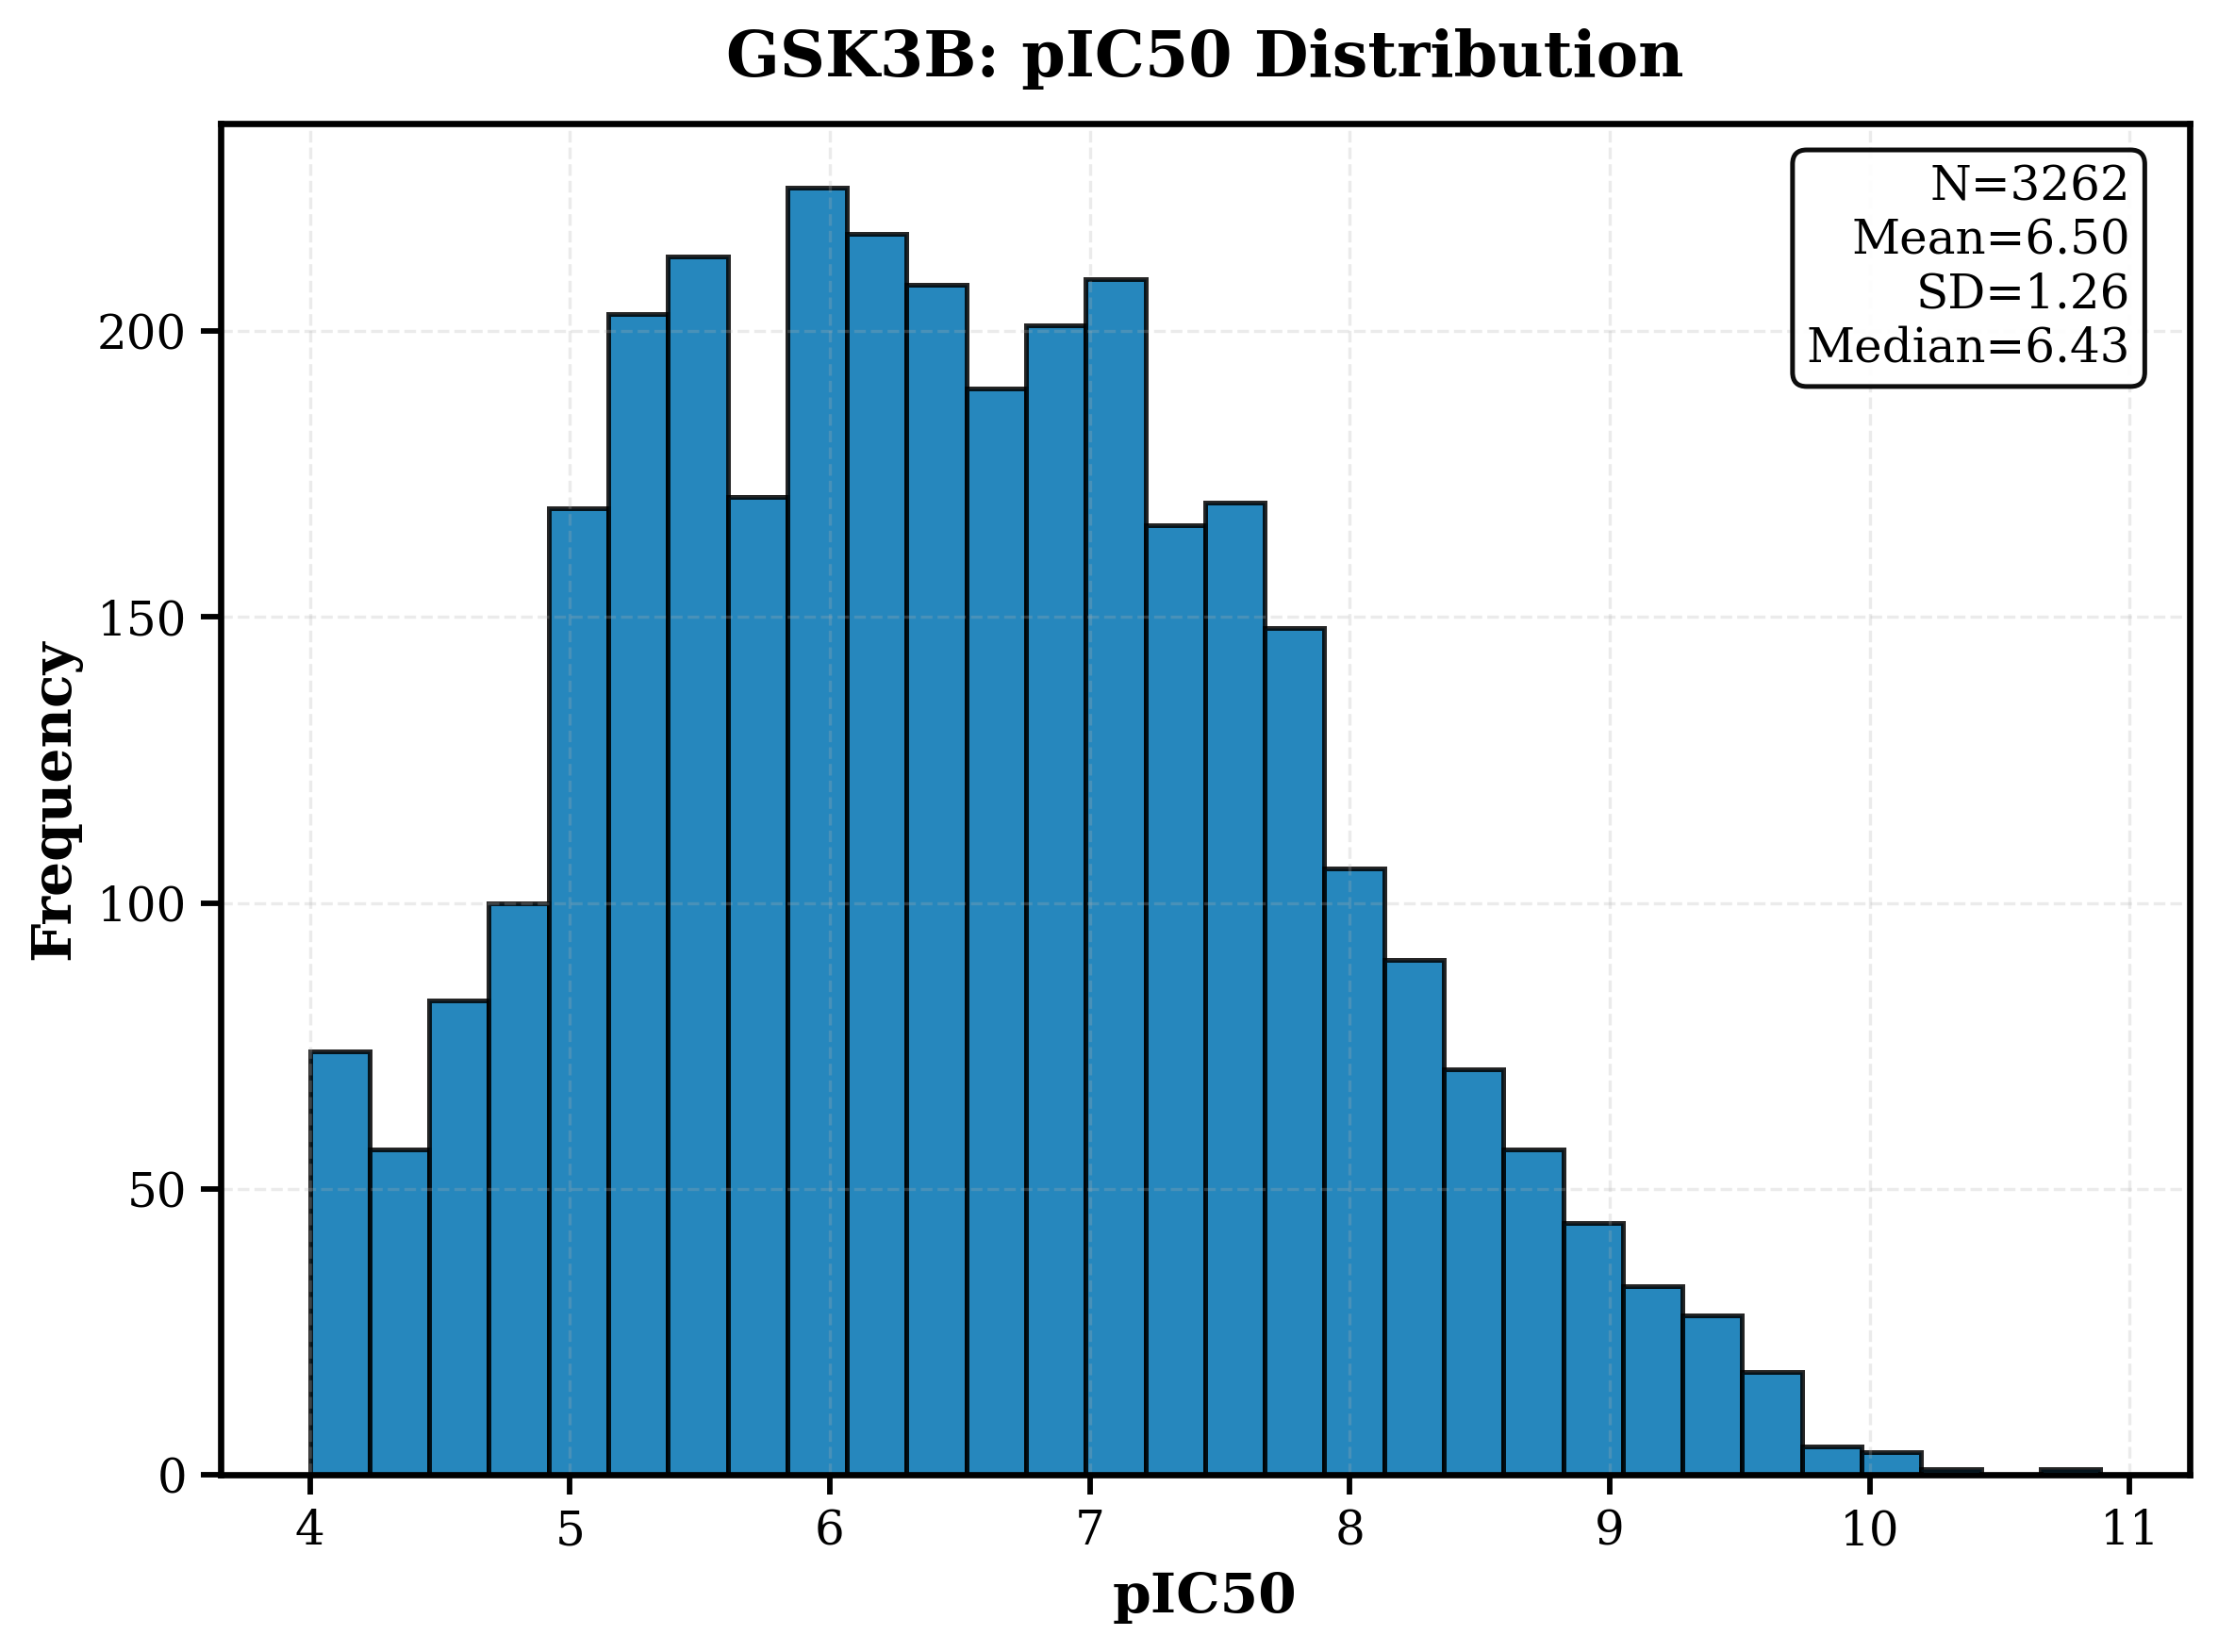

In [ ]:
# @title # FIG 1: pIC50 distribution
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(y, bins=30, edgecolor="black", linewidth=1.2, color="#0072B2", alpha=0.85)
ax.set_xlabel("pIC50", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: pIC50 Distribution", fontweight="bold", pad=12)
txt = f"N={len(y)}\nMean={y.mean():.2f}\nSD={y.std():.2f}\nMedian={y.median():.2f}"
props = dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1.2, alpha=0.95)
ax.text(0.97, 0.97, txt, transform=ax.transAxes, ha="right", va="top", fontsize=12, bbox=props)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig1_pIC50_distribution", OUT_PLOTS)
plt.show()

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig2_ModelComparison_CV_RMSE.tiff


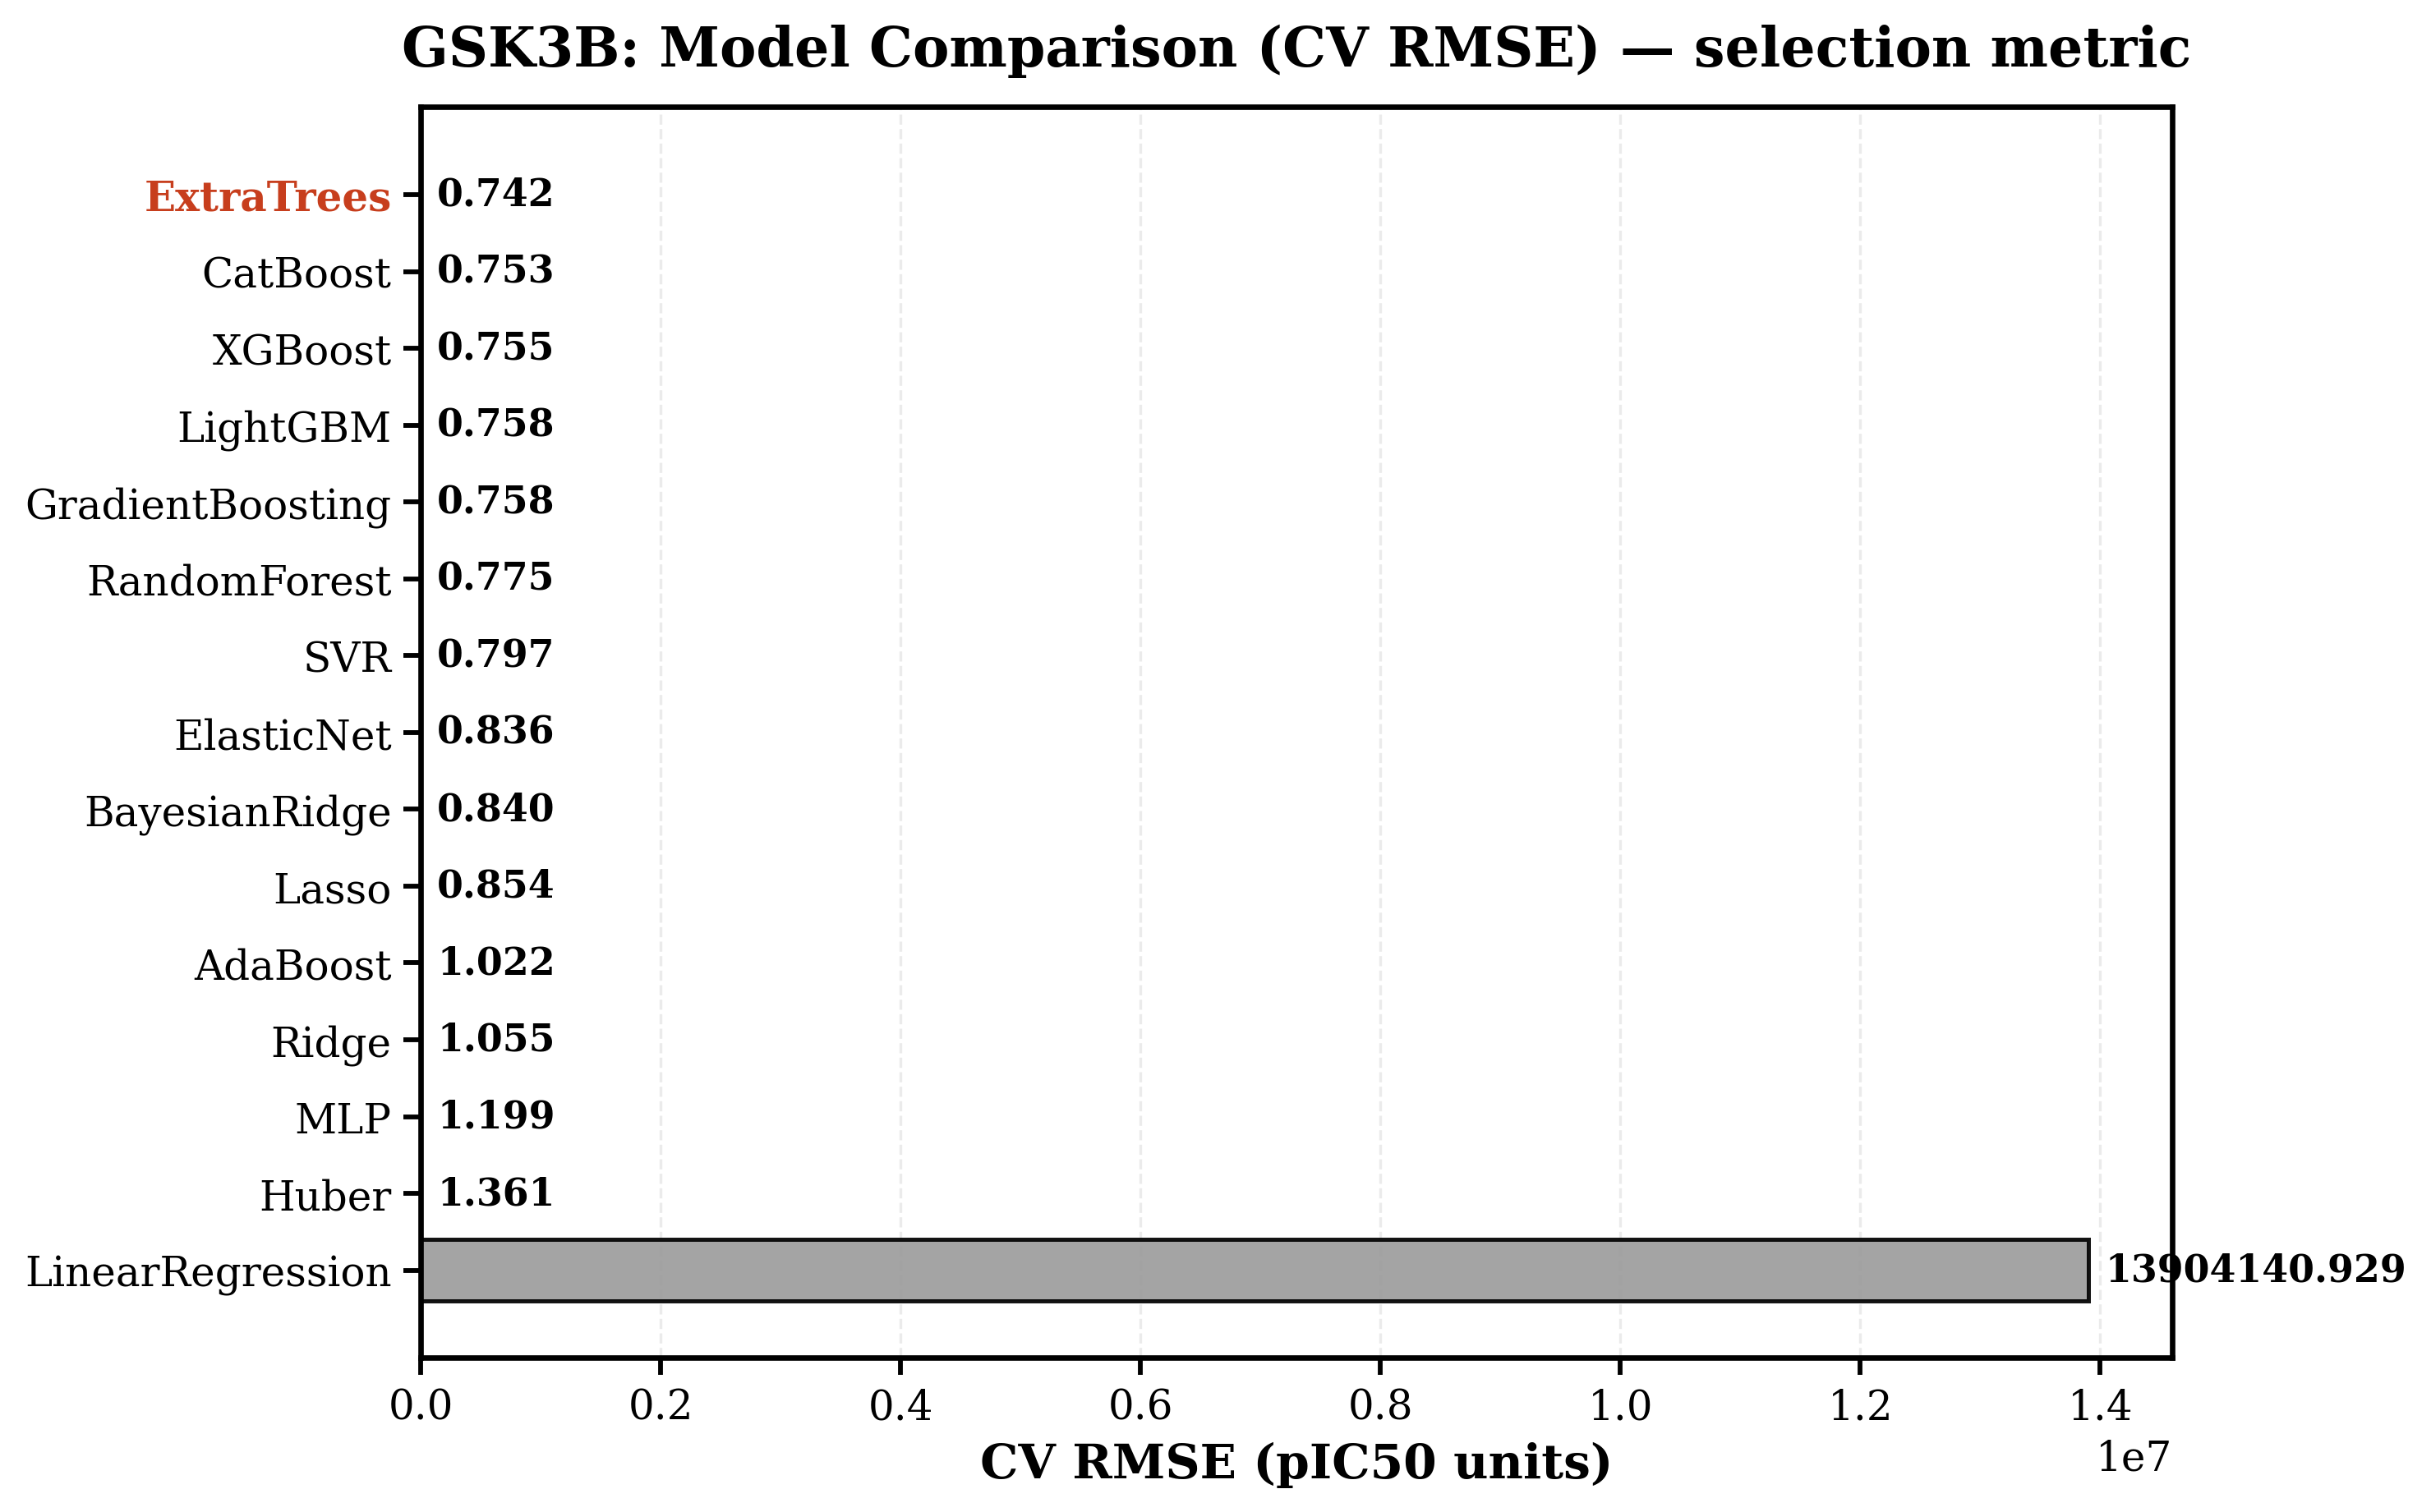

In [ ]:
# @title # FIG 2: Model comparison (CV_RMSE) — highlight best
fig, ax = plt.subplots(figsize=(10, max(6, 0.42*len(results_df))))
order = results_df.sort_values("CV_RMSE", ascending=True)
colors = [COLORS["best"] if m == best_model_name else COLORS["neutral"] for m in order["Model"]]
bars = ax.barh(order["Model"], order["CV_RMSE"], color=colors, edgecolor="black", linewidth=1.2, alpha=0.92)
ax.invert_yaxis()
ax.set_xlabel("CV RMSE (pIC50 units)", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Model Comparison (CV RMSE) — selection metric", fontweight="bold", pad=12)
ax.grid(True, axis="x", alpha=0.25, linestyle="--", linewidth=0.8)
ax.set_axisbelow(True)
for bar, v in zip(bars, order["CV_RMSE"].values):
    ax.text(v + 0.01*np.max(order["CV_RMSE"]), bar.get_y() + bar.get_height()/2,
            f"{float(v):.3f}", va="center", fontsize=11, fontweight="bold")
for lab in ax.get_yticklabels():
    if lab.get_text() == best_model_name:
        lab.set_color(COLORS["best"]); lab.set_fontweight("bold")
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig2_ModelComparison_CV_RMSE", OUT_PLOTS)
plt.show()

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig3_ModelComparison_CV_RMSE_PUBLIC.tiff


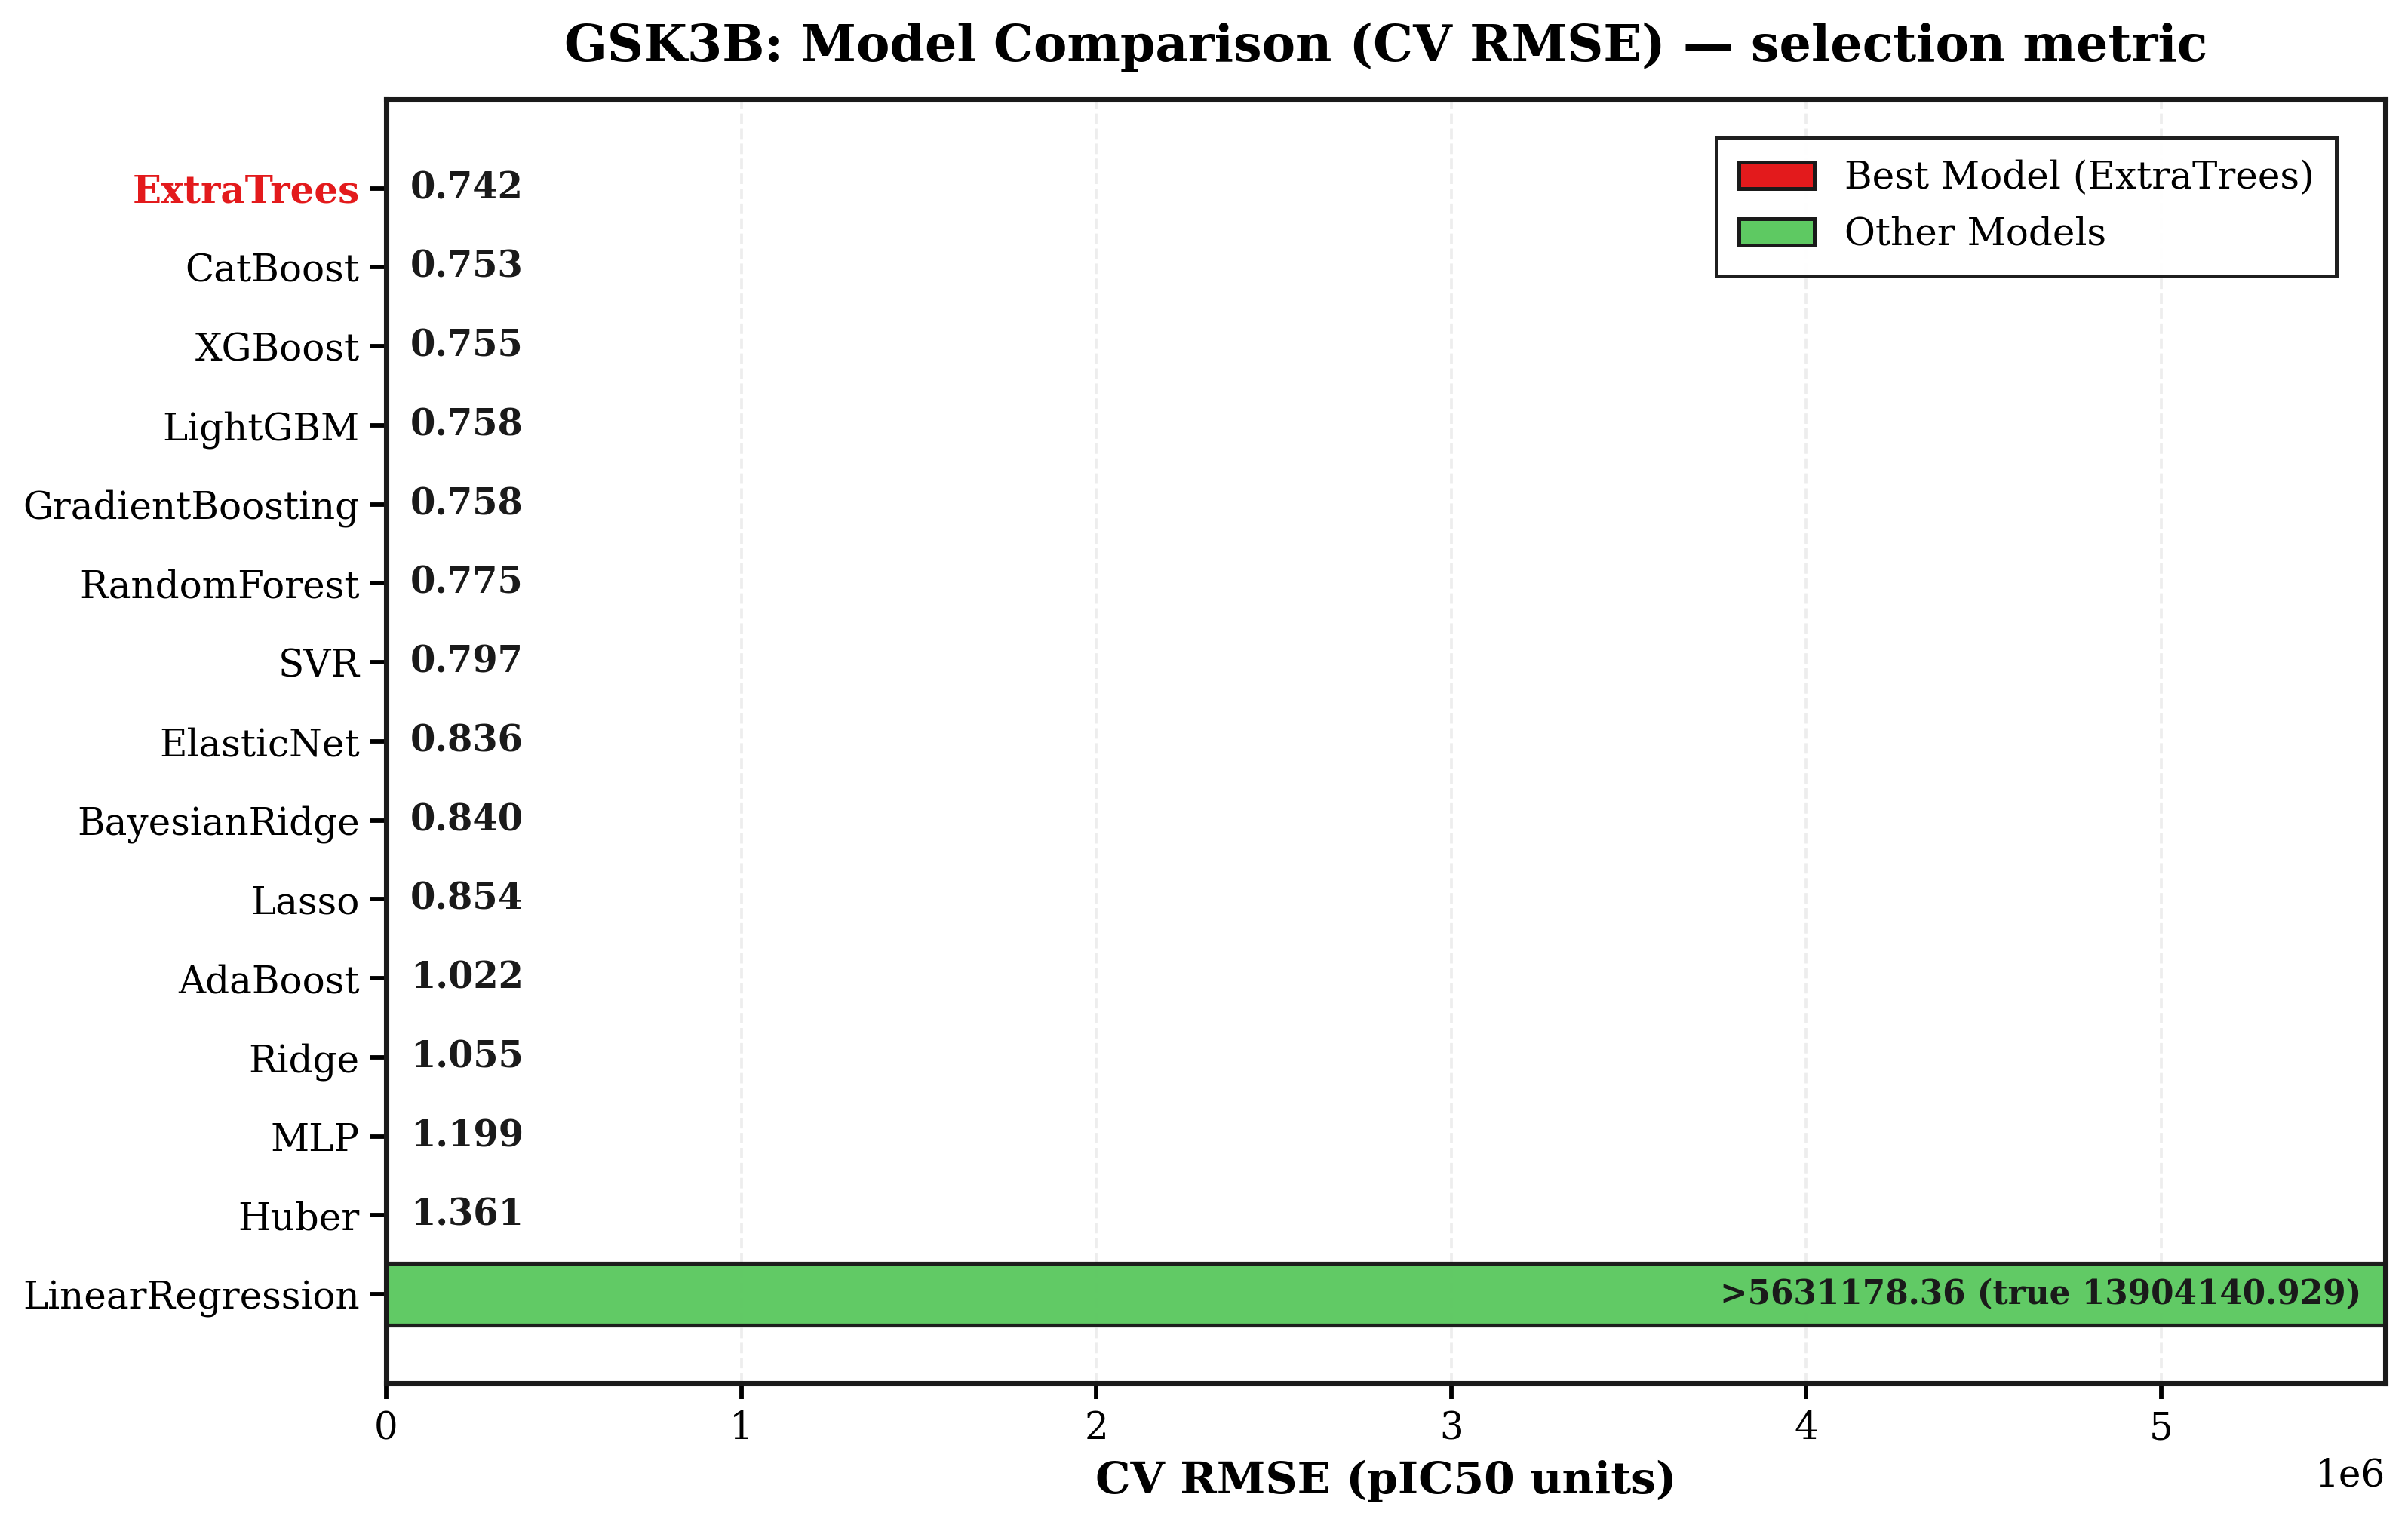

In [ ]:
# @title # PUB FIG: Model comparison (CV_RMSE) — highlight best + clean legend (inside)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- sort by CV_RMSE (lower is better) ---
order = results_df.sort_values("CV_RMSE", ascending=True).copy()
models = order["Model"].astype(str).tolist()
vals   = order["CV_RMSE"].astype(float).values

# --- publication palette (muted + one accent) ---
COLOR_OTHER = "#5EC962"   # soft cool gray (non-distracting)
COLOR_BEST  = "#E31A1C"   # elegant deep coral/red (accent)
EDGE        = "#1A1A1A"

'''colors = [
    "#FDE725", "#CDE11D", "#90D743", "#5EC962",
    "#35B779", "#1F9E89", "#26828E", "#31688E",
    "#3E4989", "#482878", "#440154"
]'''

# bar colors
bar_colors = [COLOR_BEST if m == best_model_name else COLOR_OTHER for m in models]

fig, ax = plt.subplots(figsize=(10.8, max(6.2, 0.46 * len(order))))

bars = ax.barh(
    models, vals,
    color=bar_colors,
    edgecolor=EDGE,
    linewidth=1.25,
    height=0.78,
    alpha=0.98
)
ax.invert_yaxis()

# --- smart x-limit so one extreme model doesn't ruin the figure ---
x95 = float(np.percentile(vals, 95))
xmax = float(np.max(vals))
xlim_right = min(xmax, x95 * 1.35)
ax.set_xlim(0, xlim_right)

# --- labels on bars (clip note if needed) ---
pad = 0.012 * xlim_right
for bar, v, m in zip(bars, vals, models):
    y = bar.get_y() + bar.get_height() / 2
    if v <= xlim_right:
        ax.text(v + pad, y, f"{v:.3f}", va="center", ha="left",
                fontsize=11.5, fontweight="bold", color=EDGE)
    else:
        ax.text(xlim_right - pad, y, f">{xlim_right:.2f} (true {v:.3f})",
                va="center", ha="right", fontsize=10.5, fontweight="bold", color=EDGE)

# --- ytick highlight (best model name in accent) ---
for lab in ax.get_yticklabels():
    if lab.get_text() == best_model_name:
        lab.set_color(COLOR_BEST)
        lab.set_fontweight("bold")

# --- axis + title ---
ax.set_xlabel("CV RMSE (pIC50 units)", fontweight="bold", fontsize=14)
ax.set_title(f"{OUTPUT_PREFIX}: Model Comparison (CV RMSE) — selection metric",
             fontweight="bold", fontsize=16, pad=12)

# --- grid + border (clean) ---
ax.grid(True, axis="x", alpha=0.22, linestyle="--", linewidth=0.9)
ax.set_axisbelow(True)
for s in ax.spines.values():
    s.set_linewidth(1.7)
    s.set_color(EDGE)

# --- legend INSIDE (top-right), compact box ---
legend_elements = [
    mpatches.Patch(facecolor=COLOR_BEST,  edgecolor=EDGE, label=f"Best Model ({best_model_name})"),
    mpatches.Patch(facecolor=COLOR_OTHER, edgecolor=EDGE, label="Other Models"),
]
ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    framealpha=0.98,
    edgecolor=EDGE,
    fancybox=False,
    fontsize=12,
    borderpad=0.6
)

plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig3_ModelComparison_CV_RMSE_PUBLIC", OUT_PLOTS)
plt.show()


✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig3_Parity_OOFtrain_Test.tiff


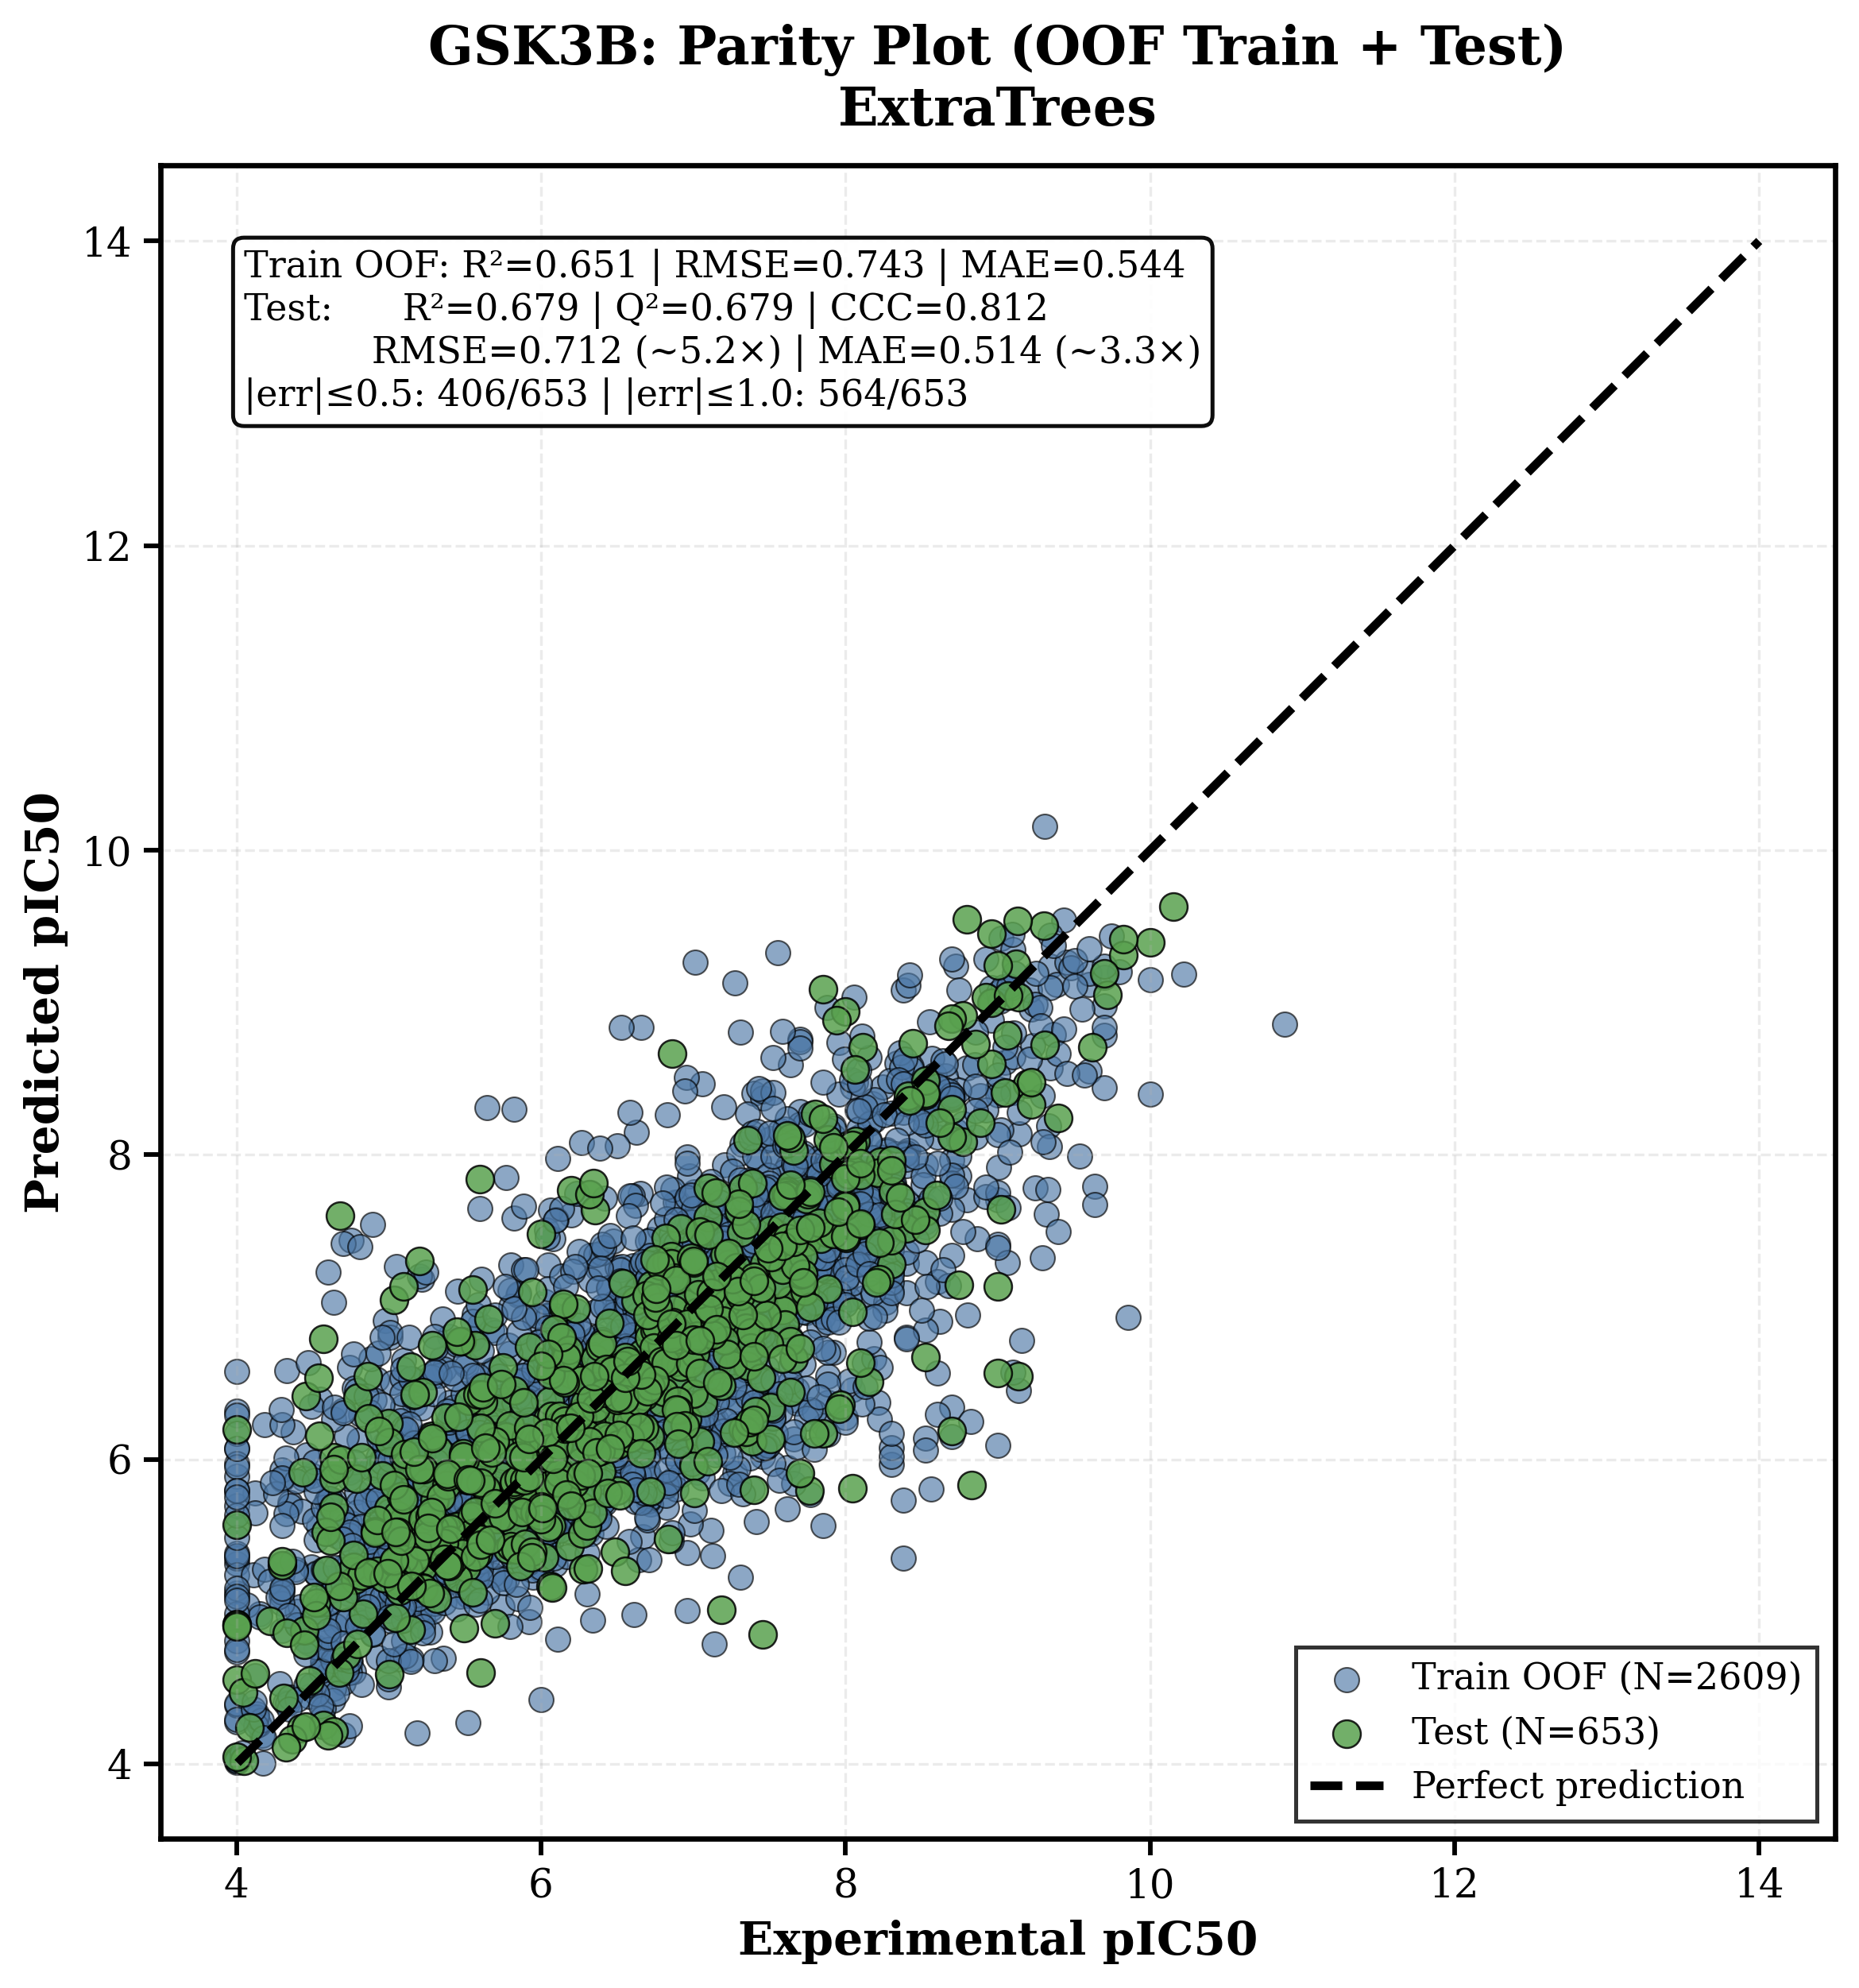

In [ ]:
# @title # FIG 3: Parity plot (OOF train + Test)
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.scatter(y_train, yhat_train_oof, s=55, alpha=0.65,
           edgecolor="black", linewidth=0.5, color=COLORS["train"],
           label=f"Train OOF (N={len(y_train)})")
ax.scatter(y_test, yhat_test, s=70, alpha=0.85,
           edgecolor="black", linewidth=0.6, color=COLORS["test"],
           label=f"Test (N={len(y_test)})")

mn = float(min(y.min(), yhat_train_oof.min(), yhat_test.min()))
mx = float(max(y.max(), yhat_train_oof.max(), yhat_test.max()))
ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2.6, color="black", label="Perfect prediction")

ax.set_xlabel("Experimental pIC50", fontweight="bold")
ax.set_ylabel("Predicted pIC50", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Parity Plot (OOF Train + Test)\n{best_model_name}", fontweight="bold", pad=12)

txt = (
    f"Train OOF: R²={r2_oof:.3f} | RMSE={rmse_oof:.3f} | MAE={mae_oof:.3f}\n"
    f"Test:      R²={r2_test:.3f} | Q²={q2_test_best:.3f} | CCC={ccc_test:.3f}\n"
    f"           RMSE={rmse_test:.3f} (~{fold_error_from_pic50_err(rmse_test):.1f}×) | "
    f"MAE={mae_test:.3f} (~{fold_error_from_pic50_err(mae_test):.1f}×)\n"
    f"|err|≤0.5: {err_le_05}/{len(y_test)} | |err|≤1.0: {err_le_10}/{len(y_test)}"
)
props = dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1.2, alpha=0.95)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, va="top", fontsize=11, bbox=props)

ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
ax.legend(loc="lower right", frameon=True, edgecolor="black", fontsize=11)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig3_Parity_OOFtrain_Test", OUT_PLOTS)
plt.show()

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig4_Residuals_vs_Predicted_Test.tiff


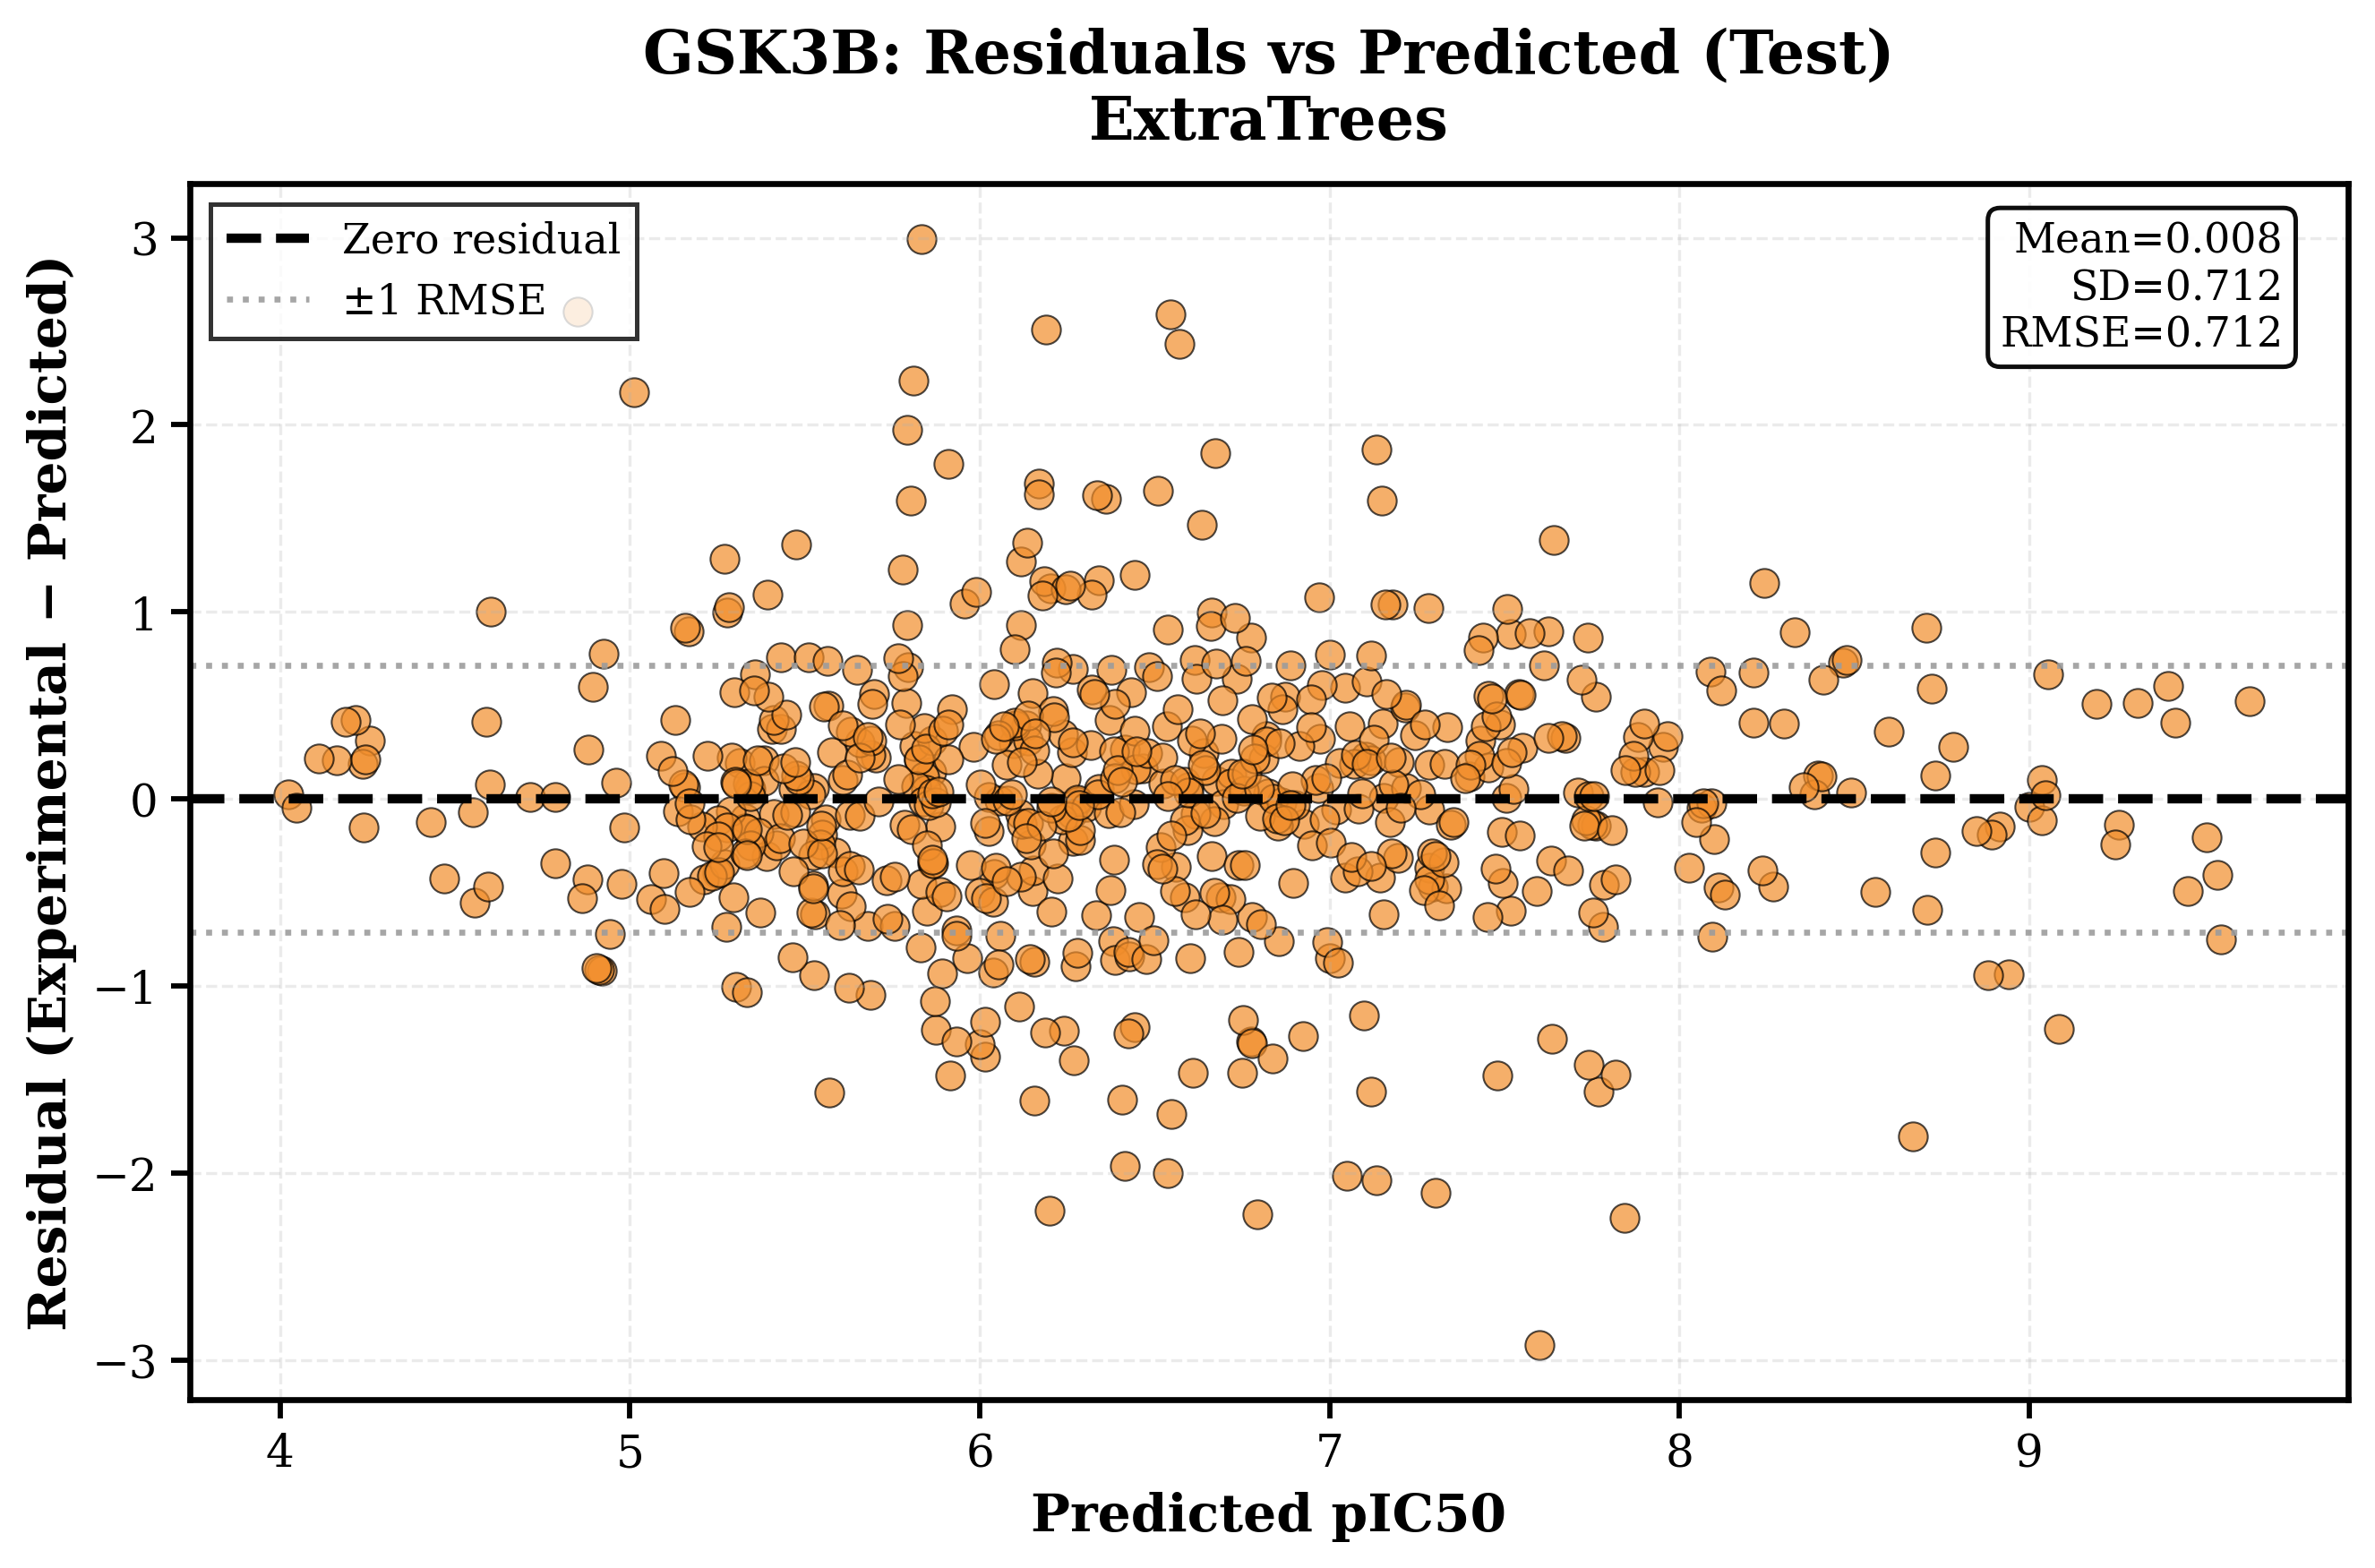

In [ ]:
# @title # FIG 4: Residuals vs Predicted (Test)
resid = np.asarray(y_test) - np.asarray(yhat_test)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(yhat_test, resid, s=60, alpha=0.7, color=COLORS["accent"],
           edgecolor="black", linewidth=0.5)
ax.axhline(0, linestyle="--", linewidth=2.5, color="black", label="Zero residual")
ax.axhline(rmse_test, linestyle=":", linewidth=1.6, color=COLORS["neutral"], alpha=0.9, label="±1 RMSE")
ax.axhline(-rmse_test, linestyle=":", linewidth=1.6, color=COLORS["neutral"], alpha=0.9)
ax.set_xlabel("Predicted pIC50", fontweight="bold")
ax.set_ylabel("Residual (Experimental − Predicted)", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Residuals vs Predicted (Test)\n{best_model_name}", fontweight="bold", pad=12)
txt = f"Mean={resid.mean():.3f}\nSD={resid.std():.3f}\nRMSE={rmse_test:.3f}"
props = dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1.2, alpha=0.95)
ax.text(0.97, 0.97, txt, transform=ax.transAxes, ha="right", va="top", fontsize=11, bbox=props)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
ax.legend(loc="upper left", frameon=True, edgecolor="black", fontsize=11)
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig4_Residuals_vs_Predicted_Test", OUT_PLOTS)
plt.show()

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig5_Residual_Distribution_Test.tiff


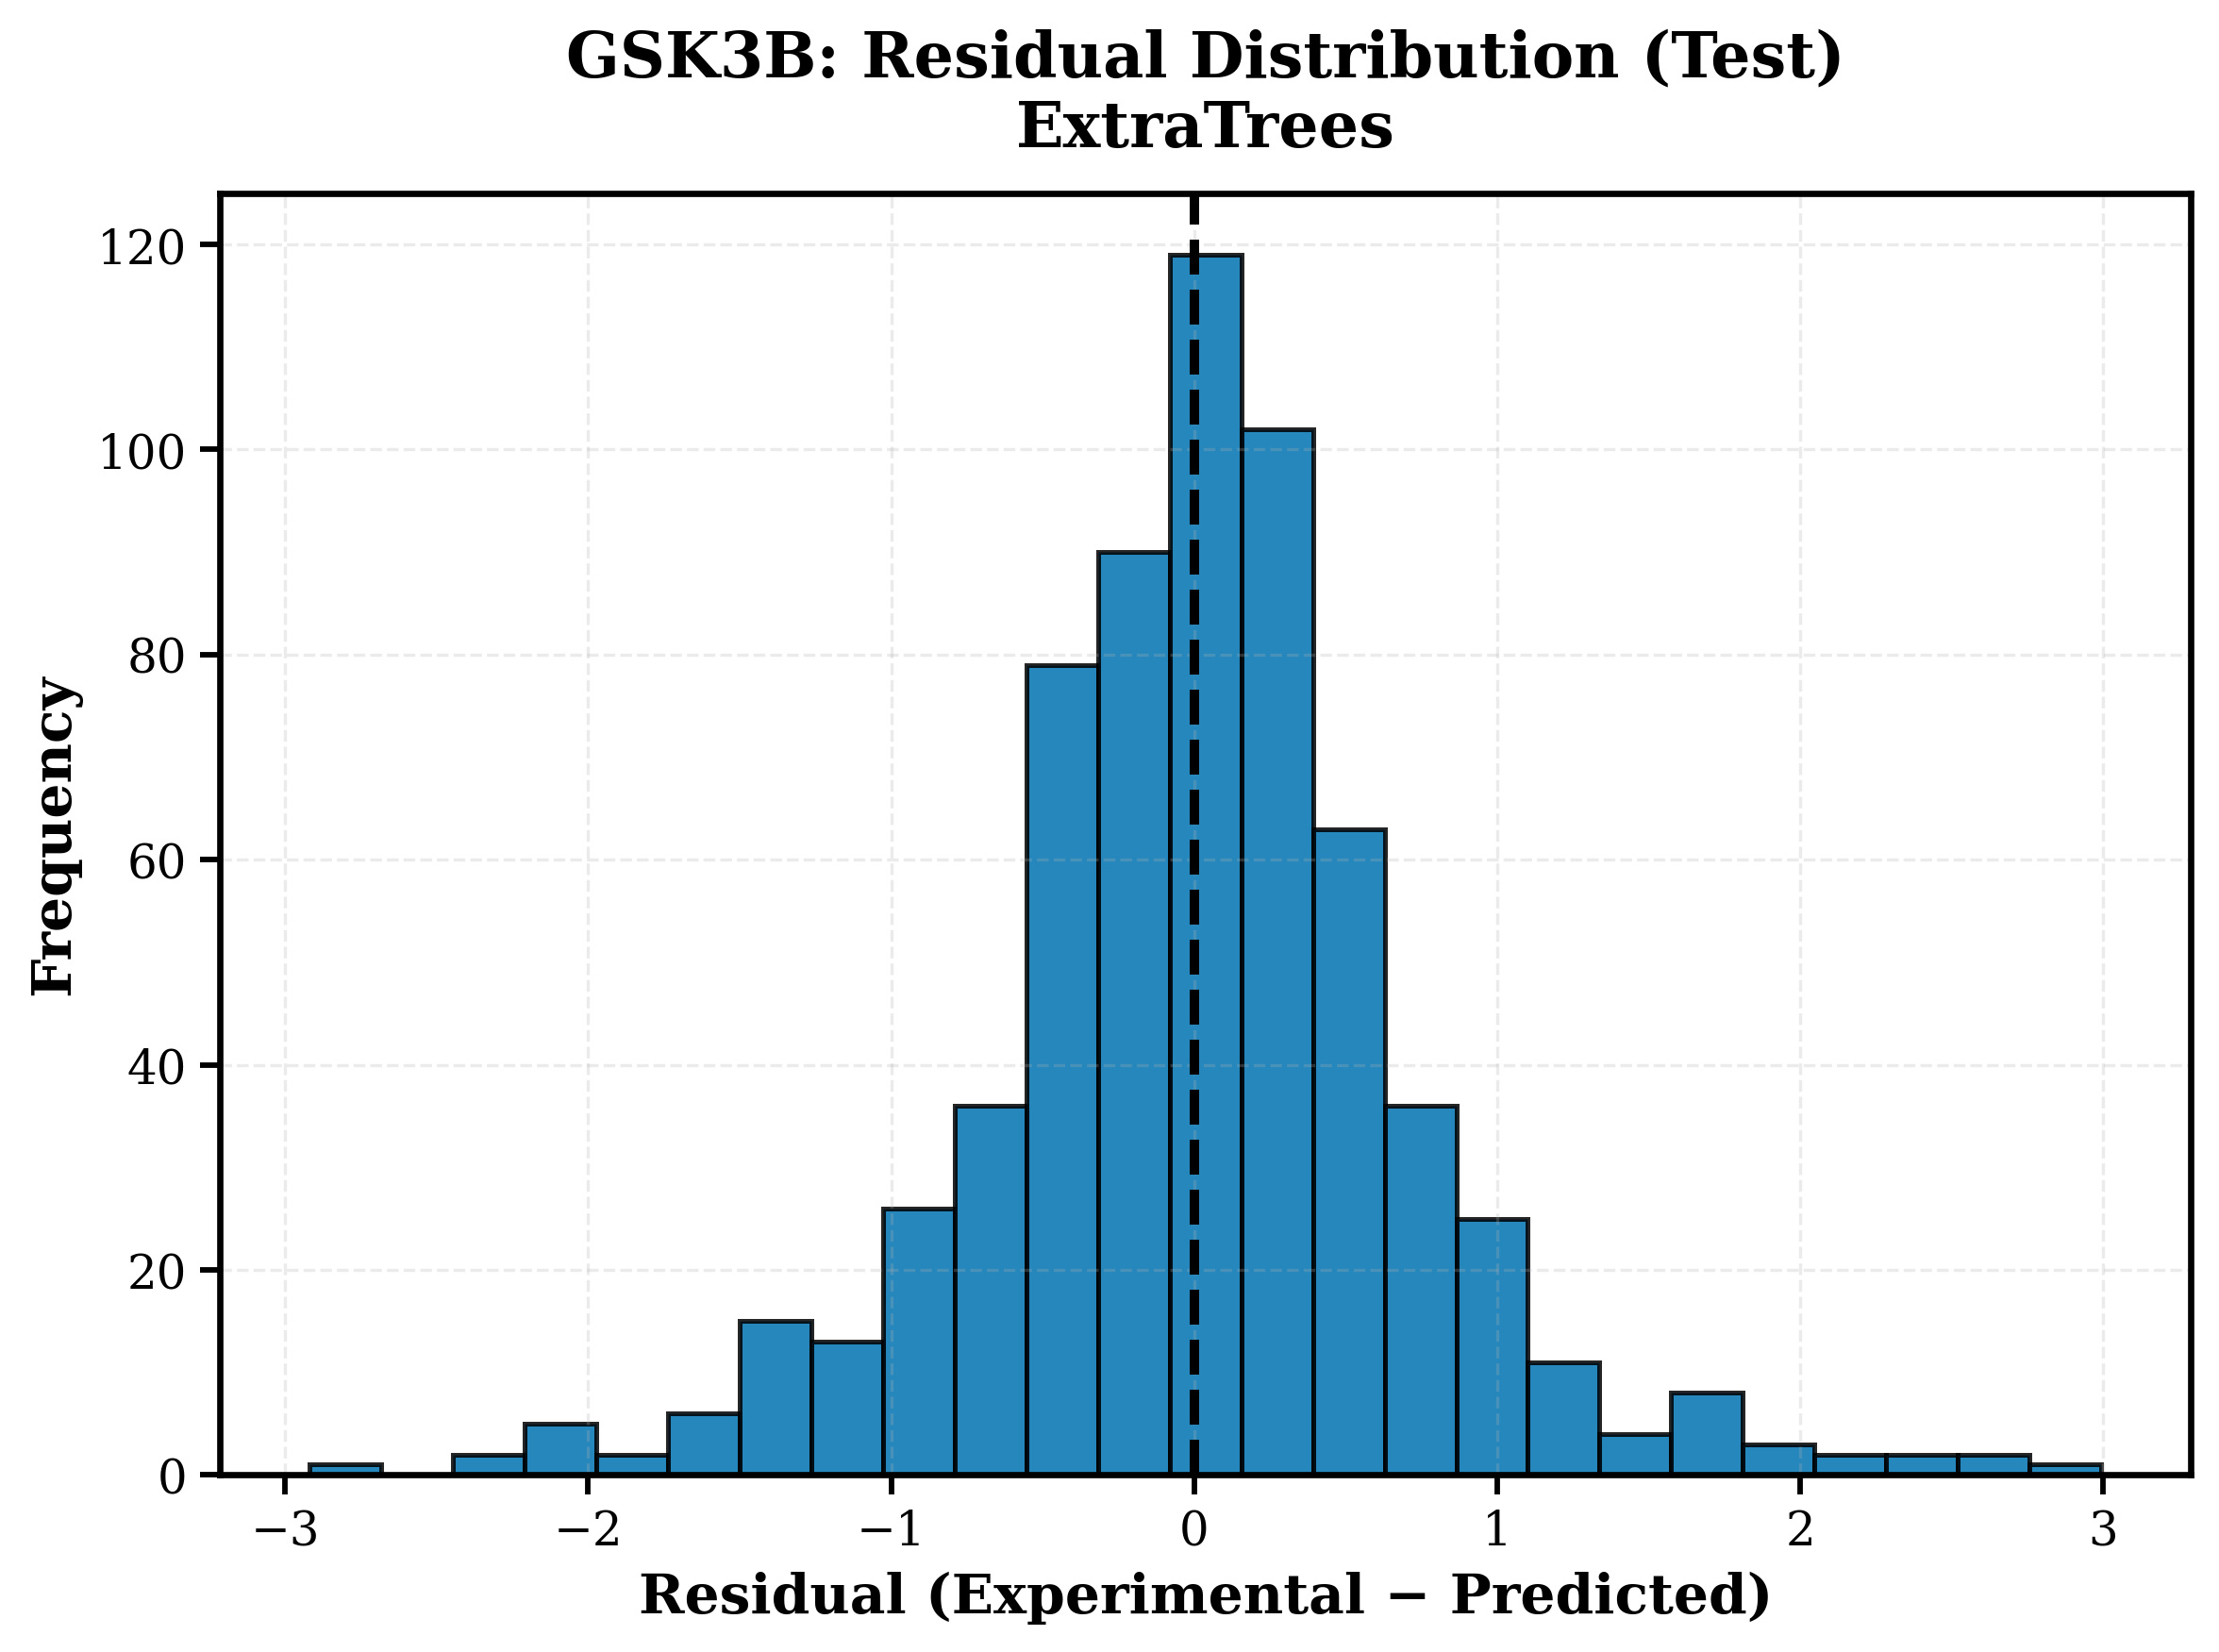

In [ ]:
# @title # FIG 5: Residual distribution (Test)
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(resid, bins=25, edgecolor="black", linewidth=1.2, alpha=0.85, color= "#0072B2")
ax.axvline(0, color="black", linestyle="--", linewidth=2.4)
ax.set_xlabel("Residual (Experimental − Predicted)", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Residual Distribution (Test)\n{best_model_name}", fontweight="bold", pad=12)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig5_Residual_Distribution_Test", OUT_PLOTS)
plt.show()

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig6_Yscrambling_R2.tiff


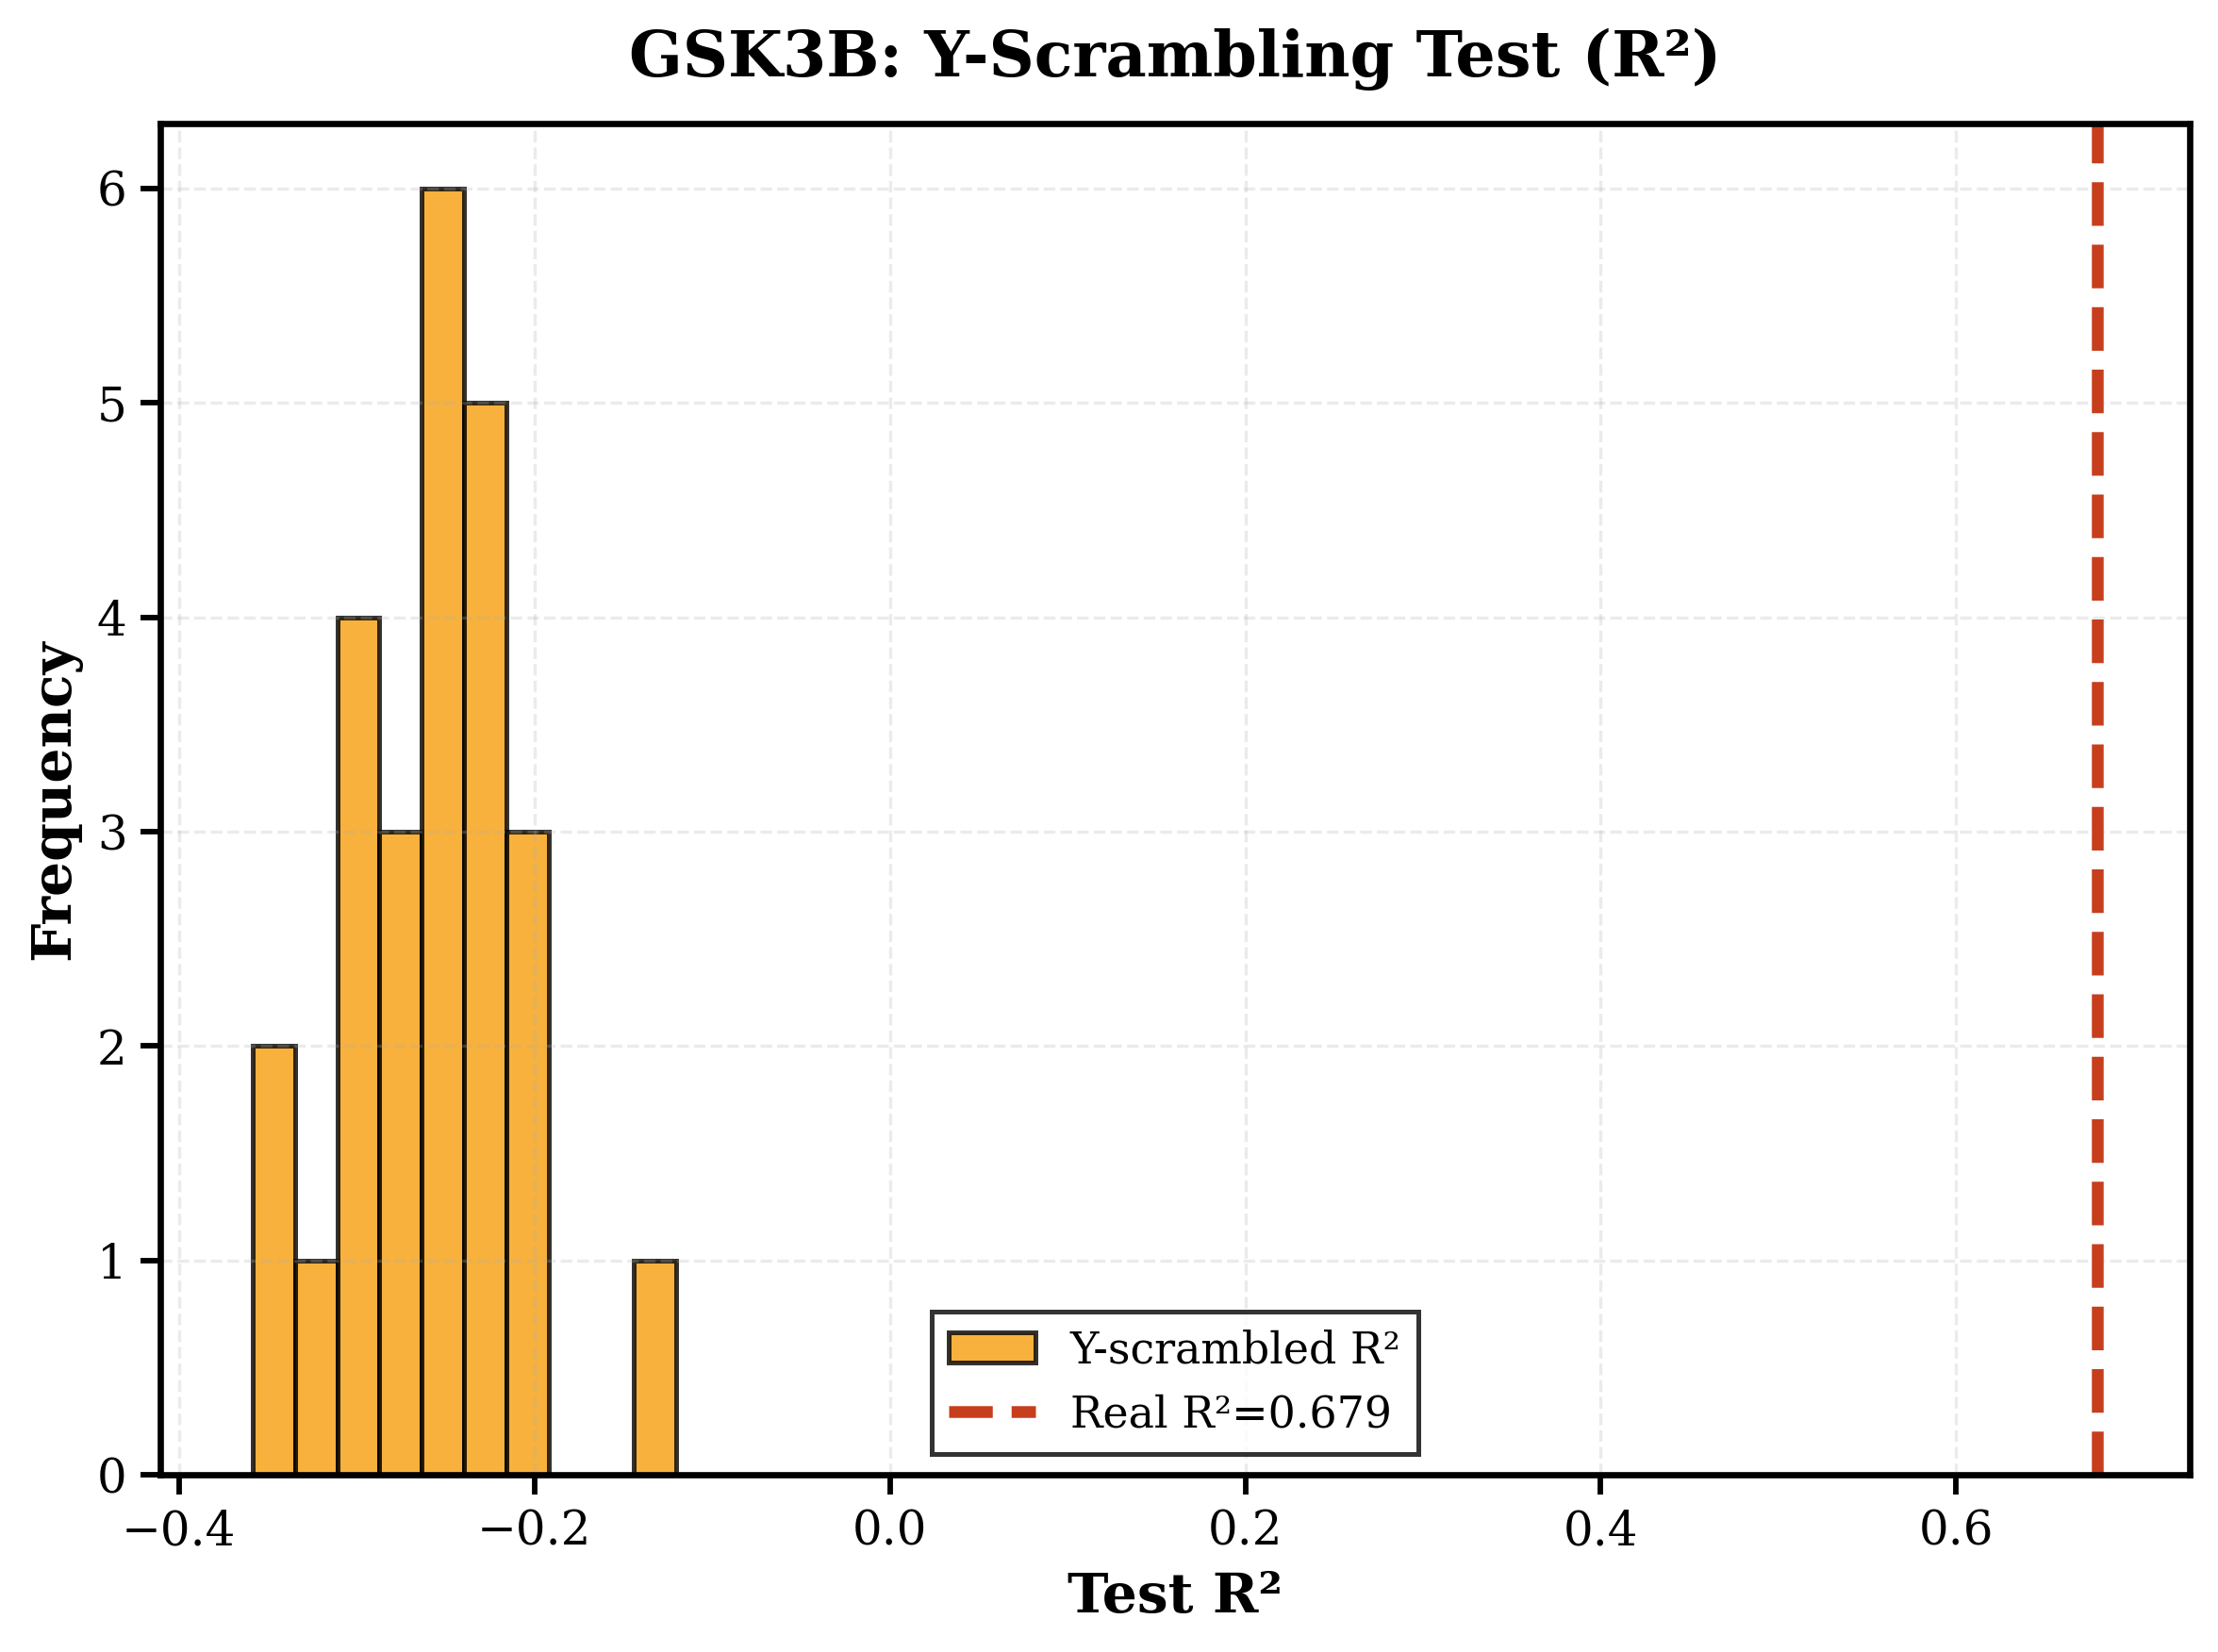

In [ ]:
# @title # FIG 6: Y-scrambling histogram (R²)
if ENABLE_Y_SCRAMBLING and len(scrambled_r2) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(scrambled_r2, bins=10, edgecolor="black", linewidth=1.2, alpha=0.8, color= "#F59E0B", label="Y-scrambled R²")
    ax.axvline(r2_test, color=COLORS["best"], linewidth=3, linestyle="--", label=f"Real R²={r2_test:.3f}")
    ax.set_xlabel("Test R²", fontweight="bold")
    ax.set_ylabel("Frequency", fontweight="bold")
    ax.set_title(f"{OUTPUT_PREFIX}: Y-Scrambling Test (R²)", fontweight="bold", pad=12)
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
    ax.legend(frameon=True, edgecolor="black", fontsize=11)
    plt.tight_layout()
    save_tiff(fig, f"{OUTPUT_PREFIX}_Fig6_Yscrambling_R2", OUT_PLOTS)
    plt.show()


📊 Generating CV scores distribution (R² + RMSE)...
✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig11_CV_scores_distribution.tiff


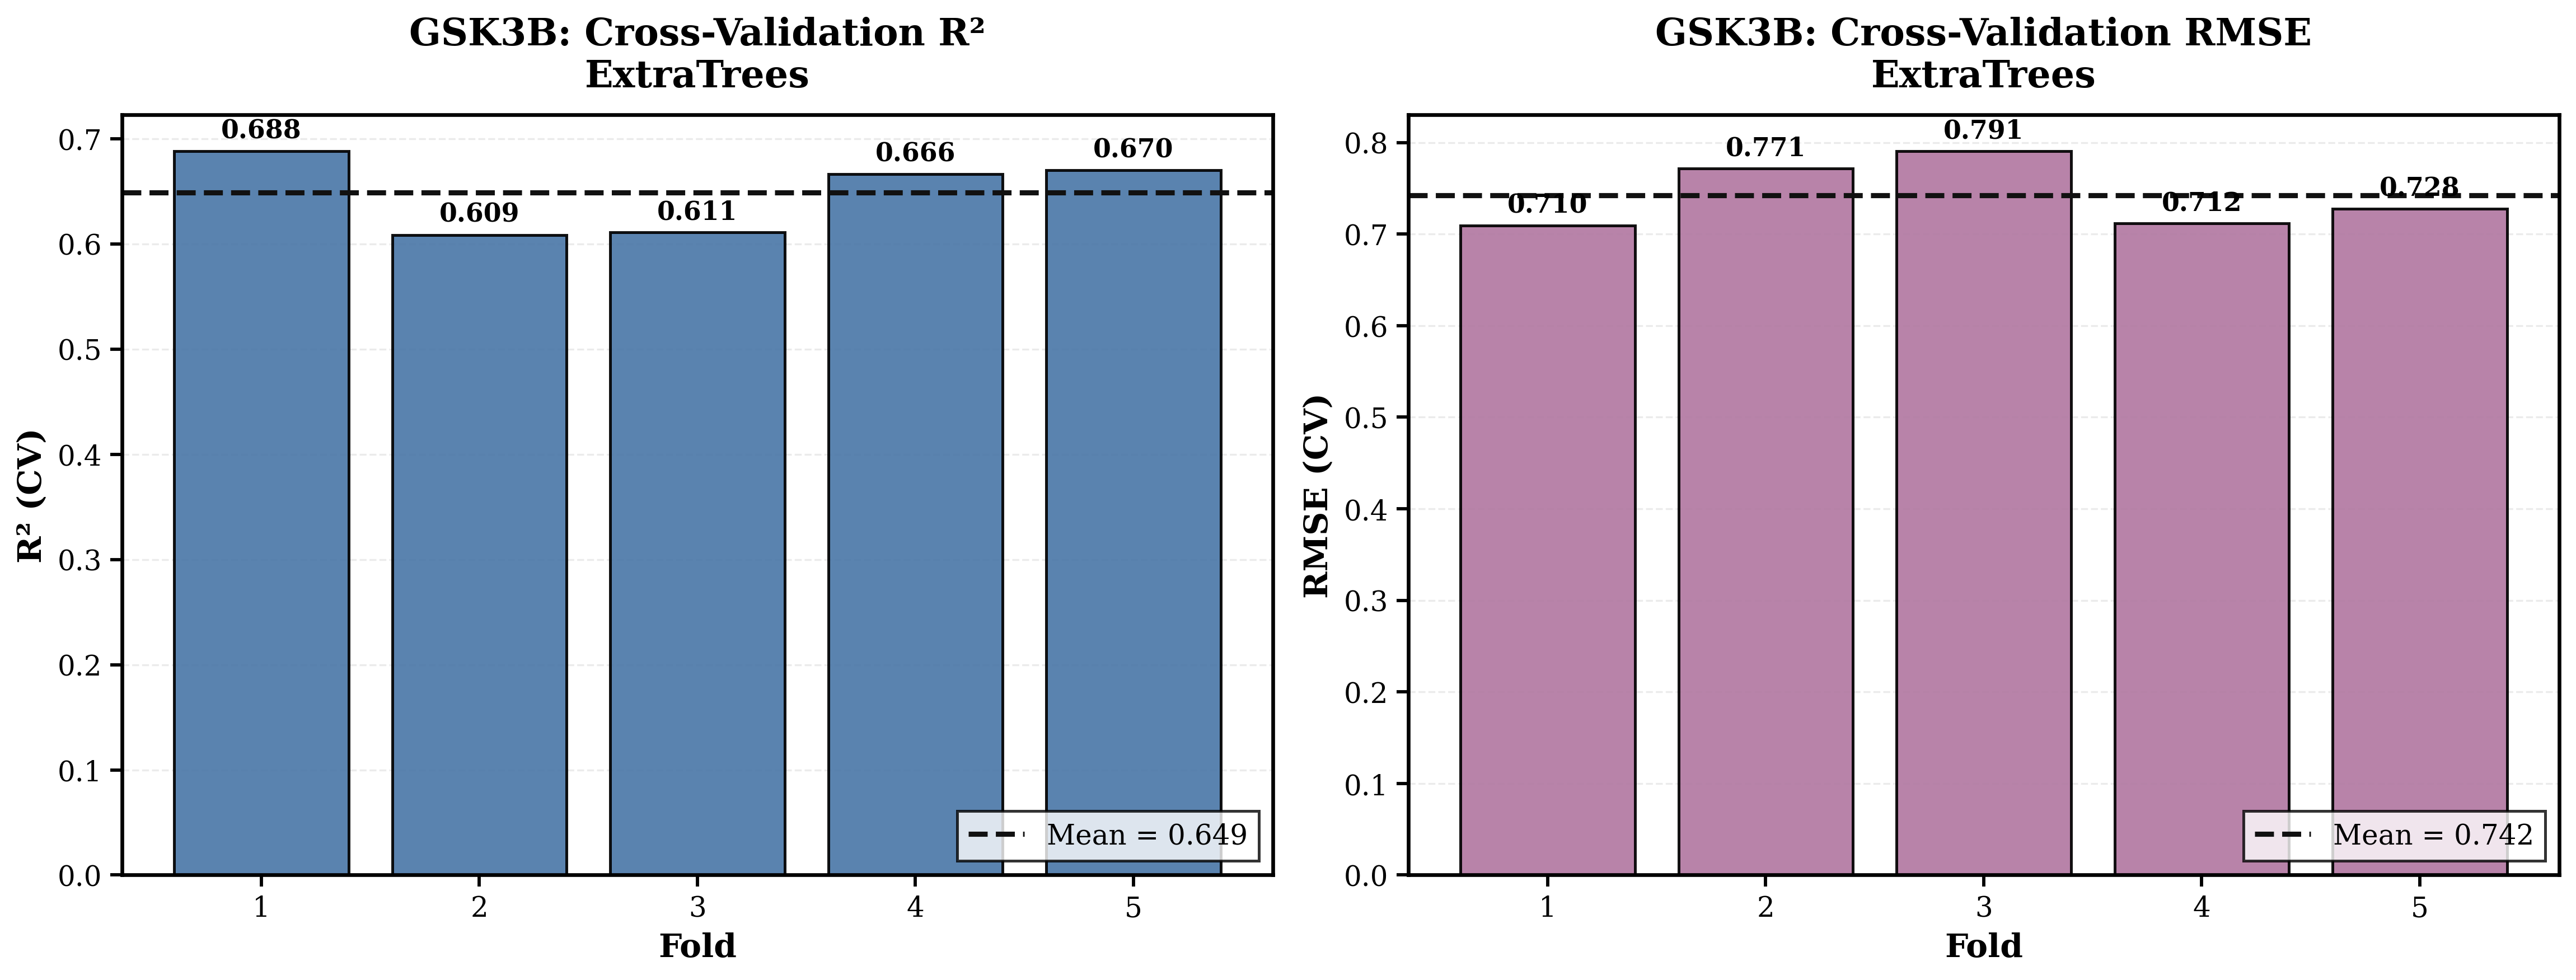

In [ ]:
# @title Default title text
# ==========================================================
# FIG 11: CV scores distribution (R² + RMSE across folds)
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

print("\n📊 Generating CV scores distribution (R² + RMSE)...")

try:
    # Fresh pipeline (no state carry-over)
    pipe_cv = Pipeline(steps=[
        ("prep", clone(preprocess)),
        ("model", type(best_model.named_steps["model"])(**best_model.named_steps["model"].get_params())),
    ])

    cv_scores_r2 = cross_val_score(
        pipe_cv, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1
    )
    cv_scores_rmse = -cross_val_score(
        pipe_cv, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1
    )

    # Publication colors (safe + clean)
    COL_FOLD_R2 = "#4C78A8"   # muted blue
    COL_FOLD_RMSE = "#B279A2" # muted purple
    COL_MEAN = "#111111"      # near black
    EDGE = "black"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 6))

    # ---- R2 folds ----
    bars1 = ax1.bar(
        range(1, CV_FOLDS + 1), cv_scores_r2,
        color=COL_FOLD_R2, edgecolor=EDGE, linewidth=1.2, alpha=0.92
    )
    ax1.axhline(cv_scores_r2.mean(), color=COL_MEAN, linestyle="--", linewidth=2.2,
                label=f"Mean = {cv_scores_r2.mean():.3f}")
    ax1.set_xlabel("Fold", fontweight="bold", fontsize=14)
    ax1.set_ylabel("R² (CV)", fontweight="bold", fontsize=14)
    ax1.set_title(f"{OUTPUT_PREFIX}: Cross-Validation R²\n{best_model_name}",
                  fontweight="bold", fontsize=16, pad=12)
    ax1.grid(True, axis="y", alpha=0.25, linestyle="--", linewidth=0.8)
    ax1.set_axisbelow(True)
    ax1.legend(loc="lower right", frameon=True, edgecolor="black", fontsize=12)

    # annotate values
    for x, v in enumerate(cv_scores_r2, start=1):
        ax1.text(x, v + 0.01*(ax1.get_ylim()[1]-ax1.get_ylim()[0]), f"{v:.3f}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

    # ---- RMSE folds ----
    bars2 = ax2.bar(
        range(1, CV_FOLDS + 1), cv_scores_rmse,
        color=COL_FOLD_RMSE, edgecolor=EDGE, linewidth=1.2, alpha=0.92
    )
    ax2.axhline(cv_scores_rmse.mean(), color=COL_MEAN, linestyle="--", linewidth=2.2,
                label=f"Mean = {cv_scores_rmse.mean():.3f}")
    ax2.set_xlabel("Fold", fontweight="bold", fontsize=14)
    ax2.set_ylabel("RMSE (CV)", fontweight="bold", fontsize=14)
    ax2.set_title(f"{OUTPUT_PREFIX}: Cross-Validation RMSE\n{best_model_name}",
                  fontweight="bold", fontsize=16, pad=12)
    ax2.grid(True, axis="y", alpha=0.25, linestyle="--", linewidth=0.8)
    ax2.set_axisbelow(True)
    ax2.legend(loc="lower right", frameon=True, edgecolor="black", fontsize=12)

    for x, v in enumerate(cv_scores_rmse, start=1):
        ax2.text(x, v + 0.01*(ax2.get_ylim()[1]-ax2.get_ylim()[0]), f"{v:.3f}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

    plt.tight_layout()
    save_tiff(fig, f"{OUTPUT_PREFIX}_Fig11_CV_scores_distribution", OUT_PLOTS)
    plt.show()

except Exception as e:
    print(f"⚠️ CV scores plot failed: {e}")


✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig7_ChemicalSpace_PCA.tiff


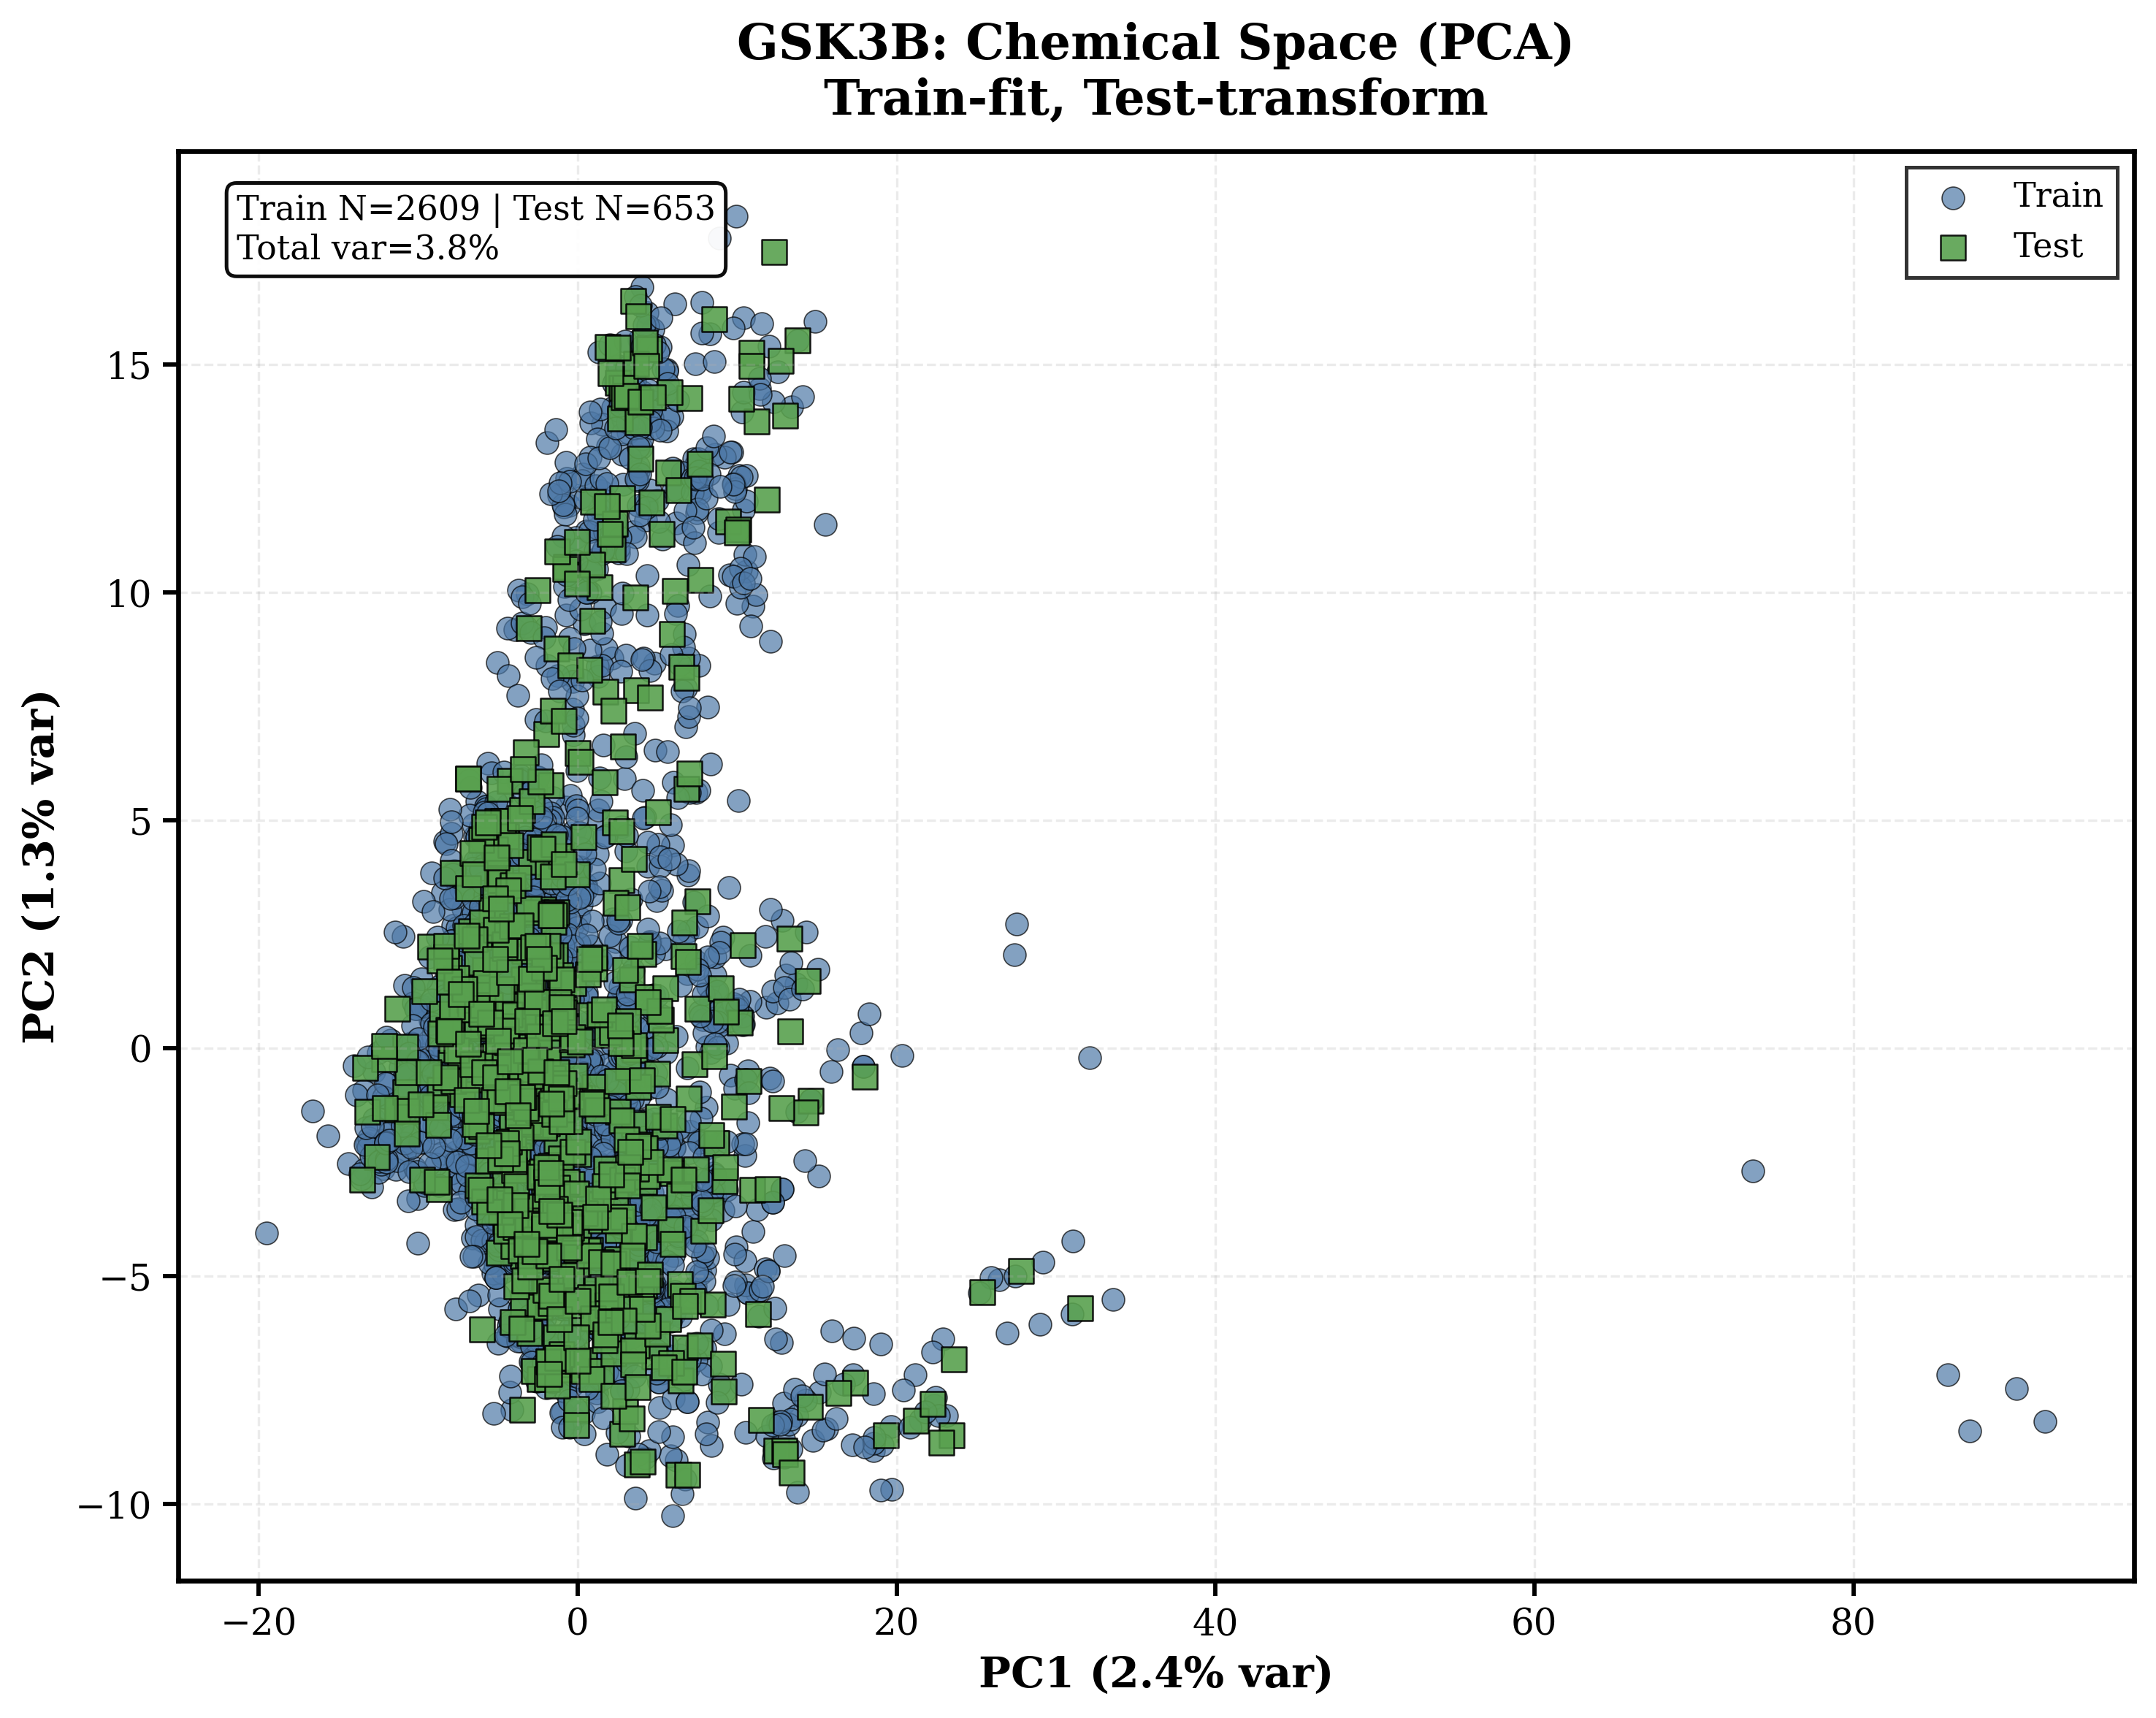

In [ ]:
# @title # FIG 7: Chemical space (PCA 2D) train-fit test-transform
if ENABLE_PCA_SPACE:
    try:
        prep_vis = clone(preprocess)
        Xtr = prep_vis.fit_transform(X_train)
        Xte = prep_vis.transform(X_test)

        pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
        Xtr2 = pca2.fit_transform(Xtr)
        Xte2 = pca2.transform(Xte)

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.scatter(Xtr2[:,0], Xtr2[:,1], s=55, alpha=0.7, color=COLORS["train"],
                   edgecolor="black", linewidth=0.4, label="Train")
        ax.scatter(Xte2[:,0], Xte2[:,1], s=70, alpha=0.9, color=COLORS["test"],
                   edgecolor="black", linewidth=0.6, marker="s", label="Test")

        ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)", fontweight="bold")
        ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)", fontweight="bold")
        ax.set_title(f"{OUTPUT_PREFIX}: Chemical Space (PCA)\nTrain-fit, Test-transform",
                     fontweight="bold", pad=12)
        ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
        ax.legend(frameon=True, edgecolor="black", fontsize=11)

        txt = f"Train N={len(X_train)} | Test N={len(X_test)}\nTotal var={pca2.explained_variance_ratio_.sum()*100:.1f}%"
        props = dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1.2, alpha=0.95)
        ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", fontsize=11, bbox=props)

        plt.tight_layout()
        save_tiff(fig, f"{OUTPUT_PREFIX}_Fig7_ChemicalSpace_PCA", OUT_PLOTS)
        plt.show()
    except Exception as e:
        print("⚠️ PCA chemical space failed:", e)

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig8_WilliamsPlot_PCAleverage.tiff


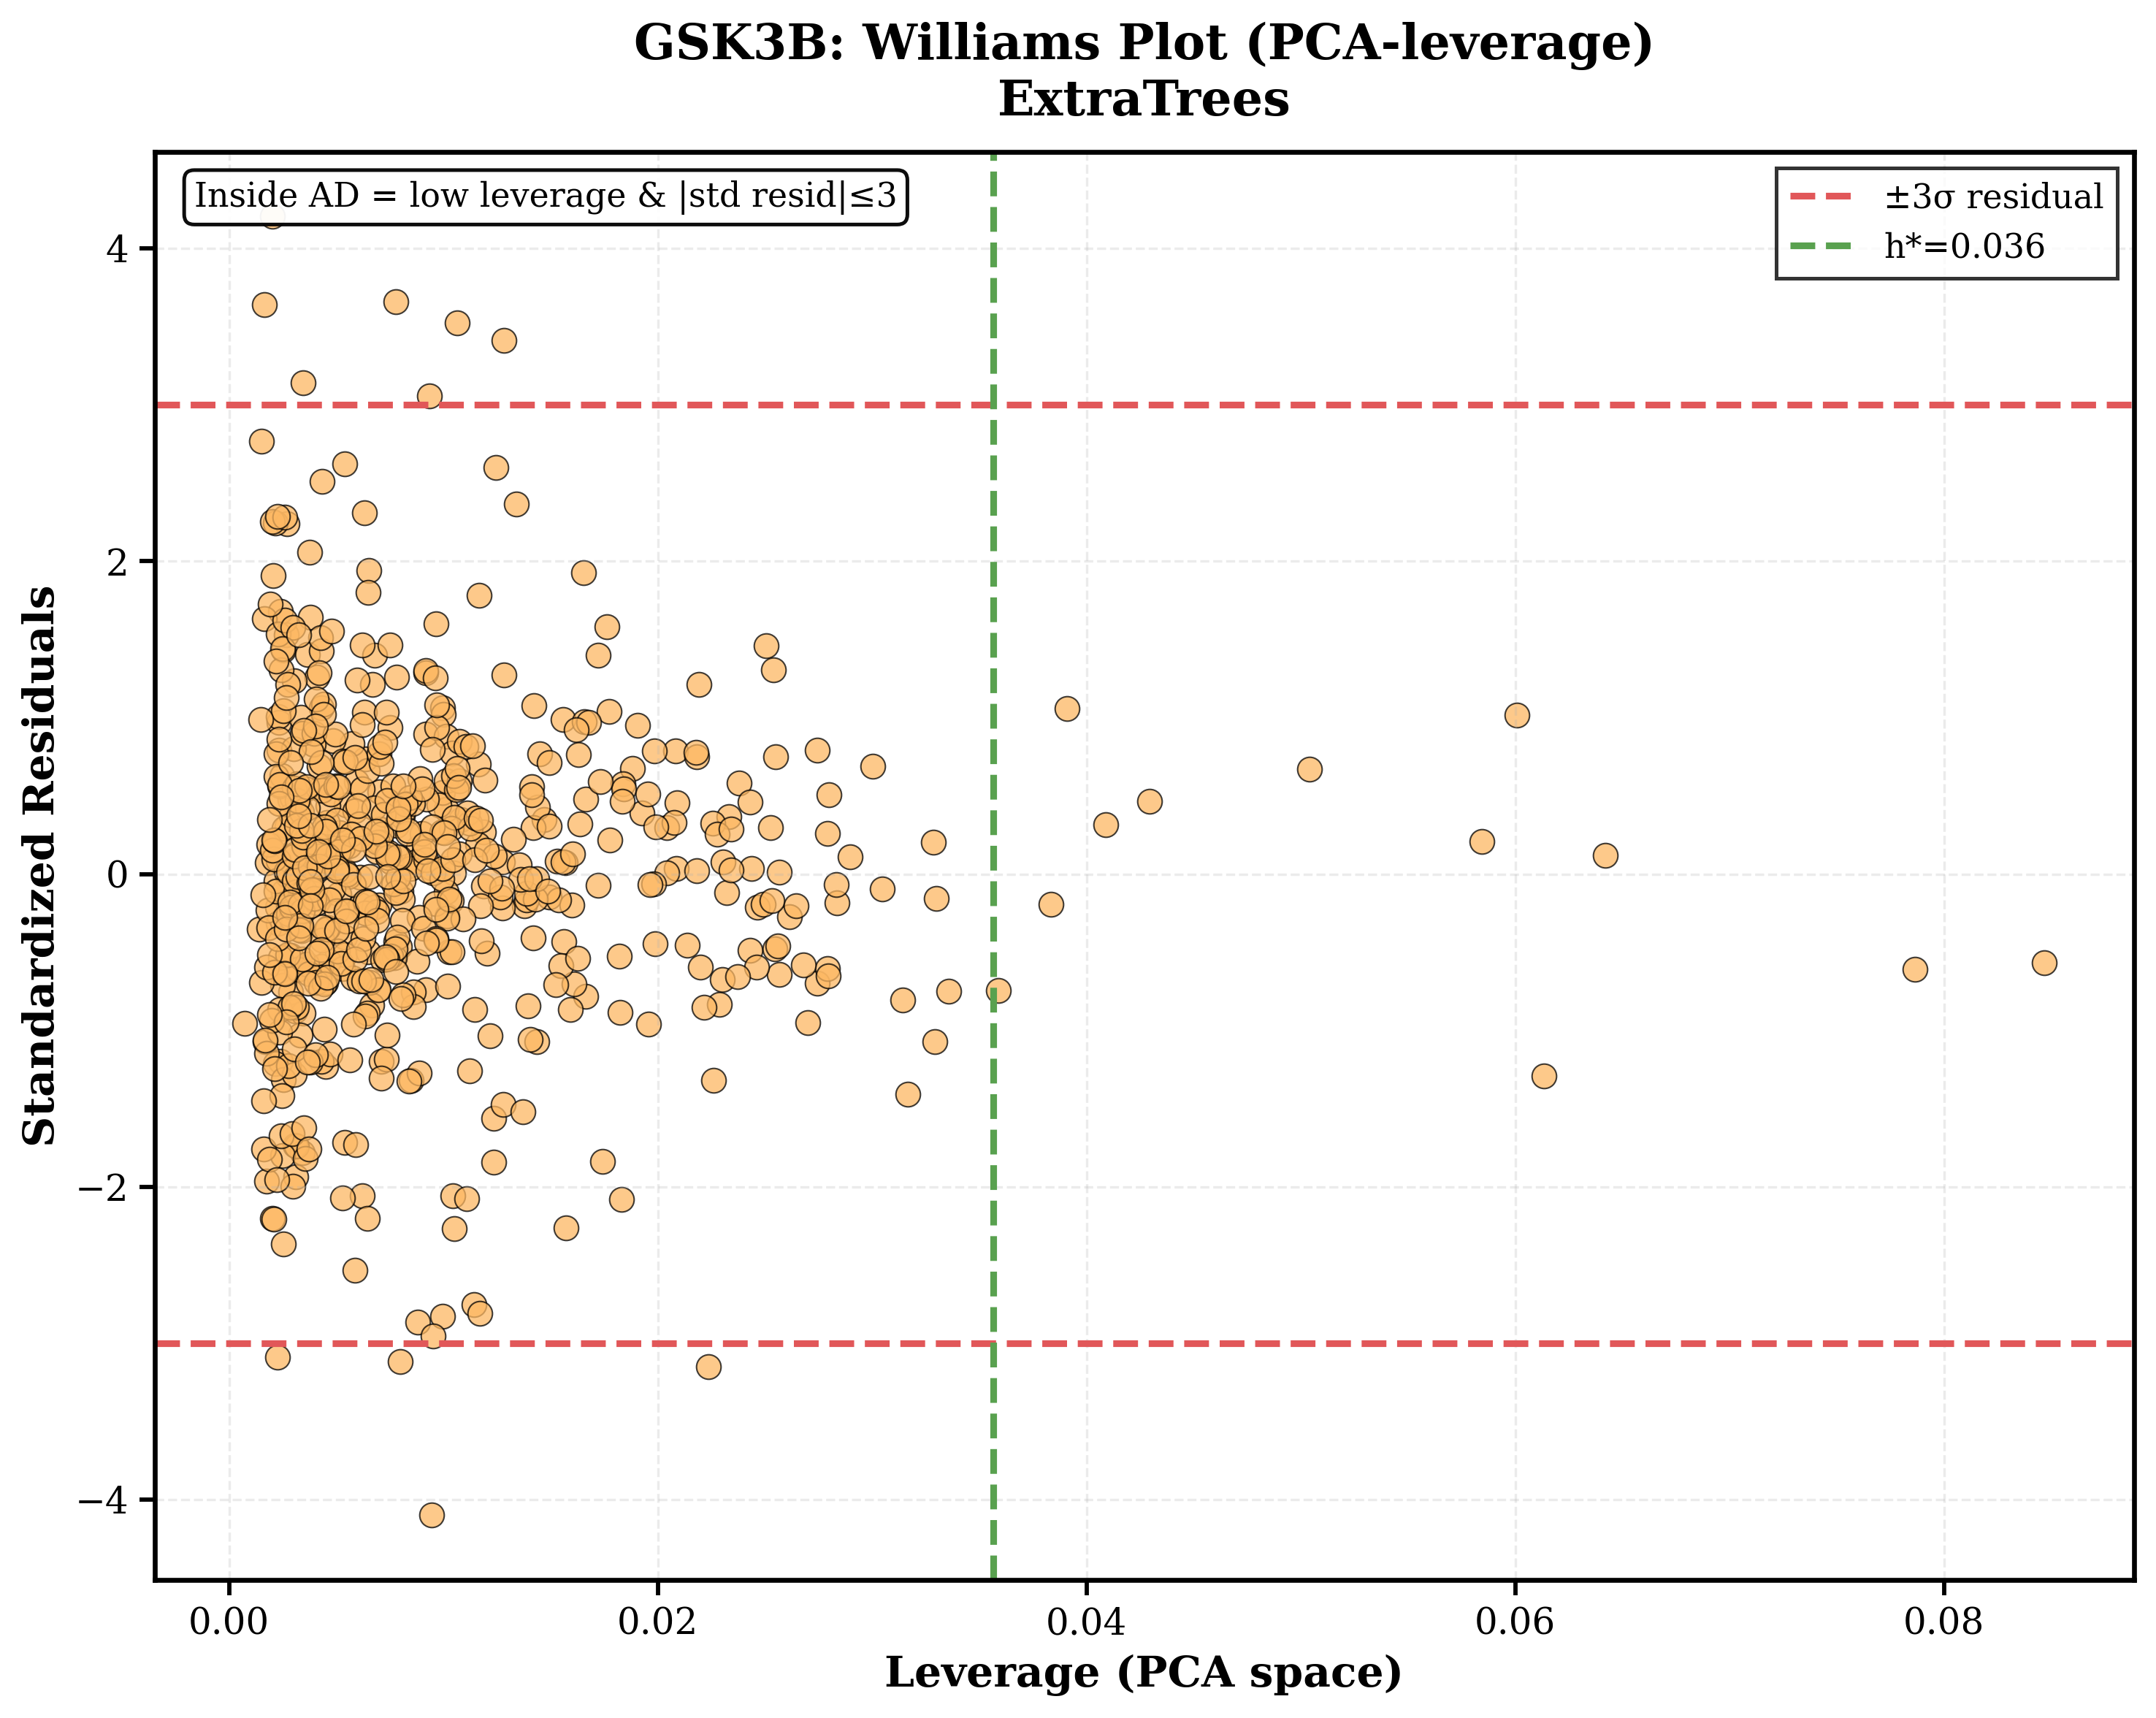

In [ ]:
# @title # FIG 8: Williams plot (PCA-leverage) — practical for high-dimensional descriptors
try:
    prep_ad = best_model.named_steps["prep"]
    Xtr_scaled = prep_ad.transform(X_train)
    Xte_scaled = prep_ad.transform(X_test)

    A = int(min(AD_PCA_COMPONENTS, Xtr_scaled.shape[0]-2, Xtr_scaled.shape[1]))
    A = max(2, A)
    pcaA = PCA(n_components=A, random_state=RANDOM_STATE)
    Ttr = pcaA.fit_transform(Xtr_scaled)
    Tte = pcaA.transform(Xte_scaled)

    # leverage in PCA score space: h = t (T' T)^-1 t'
    TT_inv = np.linalg.pinv(Ttr.T @ Ttr)
    h_test = np.sum((Tte @ TT_inv) * Tte, axis=1)
    h_star = float(3 * (A + 1) / max(len(Ttr), 1))

    std_resid = resid / (np.std(resid) + 1e-12)

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(h_test, std_resid, s=65, alpha=0.75,
                    edgecolor="black", linewidth=0.5, color=COLORS["primary"])

    ax.axhline(3,  color=COLORS["highlight"], linestyle="--", linewidth=2.2, label="±3σ residual")
    ax.axhline(-3, color=COLORS["highlight"], linestyle="--", linewidth=2.2)
    ax.axvline(h_star, color=COLORS["secondary"], linestyle="--", linewidth=2.2, label=f"h*={h_star:.3f}")

    ax.set_xlabel("Leverage (PCA space)", fontweight="bold")
    ax.set_ylabel("Standardized Residuals", fontweight="bold")
    ax.set_title(f"{OUTPUT_PREFIX}: Williams Plot (PCA-leverage)\n{best_model_name}",
                 fontweight="bold", pad=12)
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
    ax.legend(frameon=True, edgecolor="black", fontsize=11, loc="best")

    props = dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1.2, alpha=0.95)
    ax.text(0.02, 0.98, "Inside AD = low leverage & |std resid|≤3",
            transform=ax.transAxes, va="top", fontsize=11, bbox=props)

    plt.tight_layout()
    save_tiff(fig, f"{OUTPUT_PREFIX}_Fig8_WilliamsPlot_PCAleverage", OUT_PLOTS)
    plt.show()
except Exception as e:
    print("⚠️ Williams plot failed:", e)

✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig9_FeatureImportance_Top25.tiff


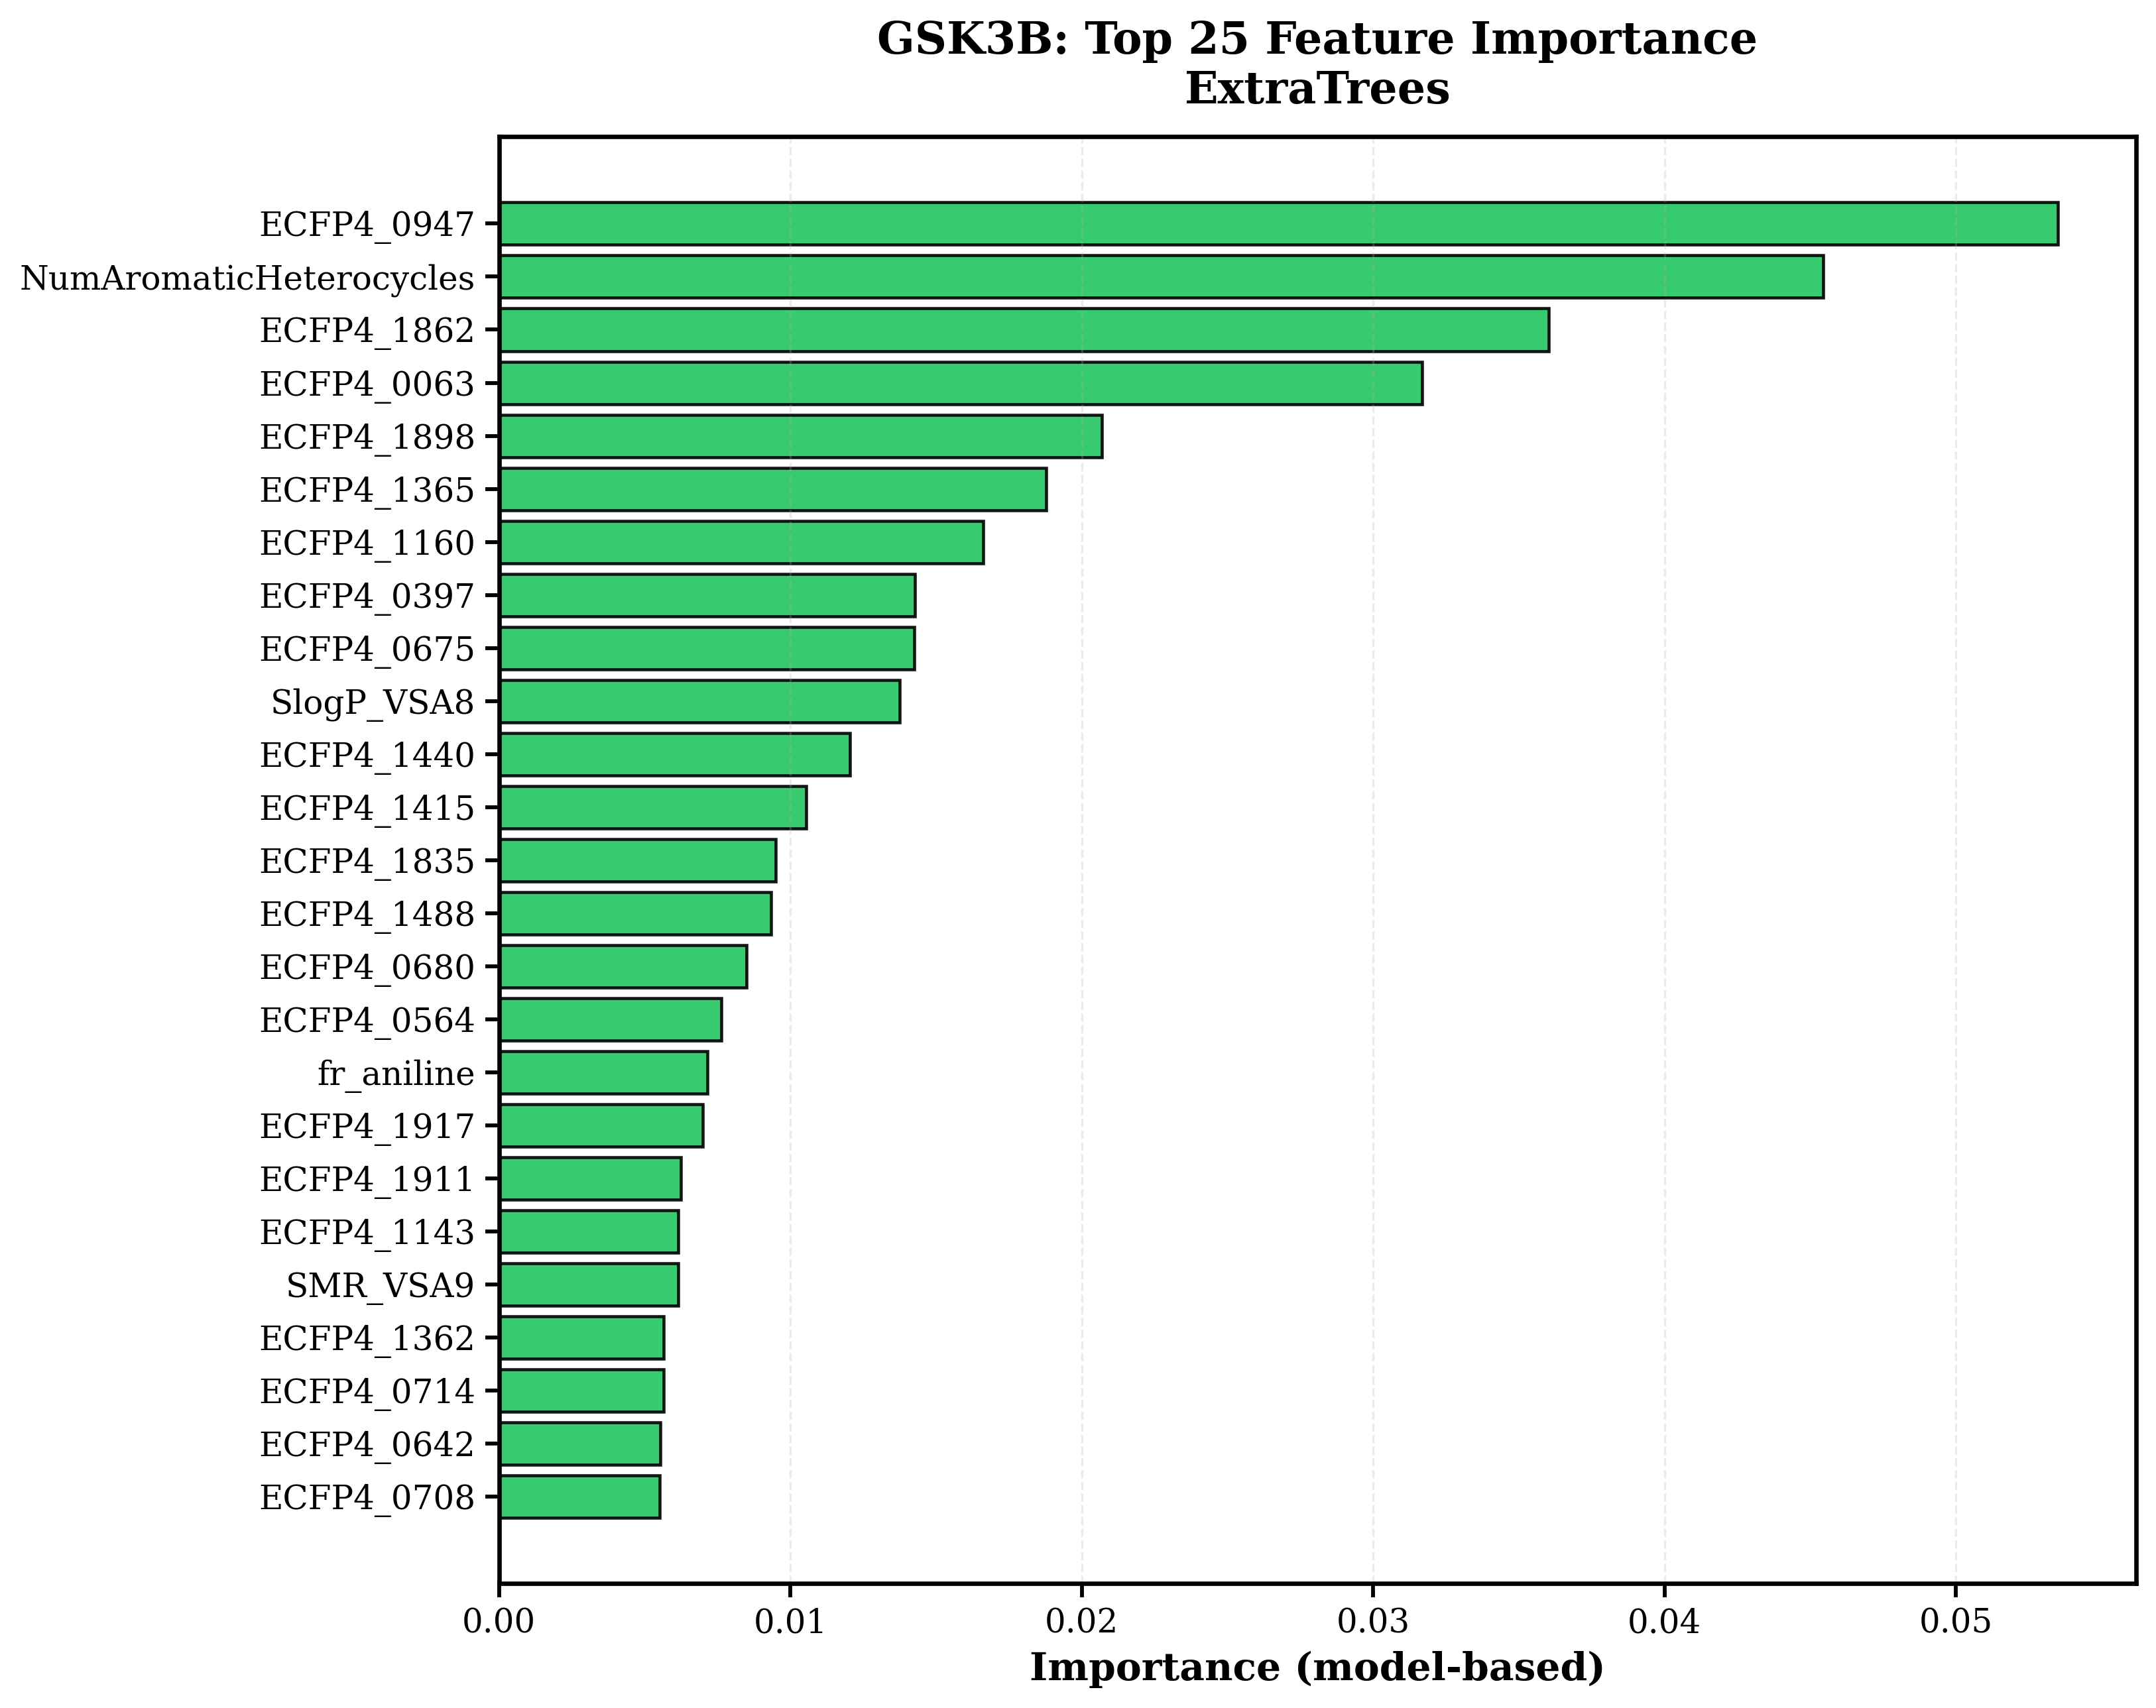

In [ ]:
# @title # 18) FAST FEATURE IMPORTANCE (Top N)
# =========================
if ENABLE_FEATURE_IMPORTANCE:
    try:
        mdl = best_model.named_steps["model"]
        importances = None

        if hasattr(mdl, "feature_importances_"):
            importances = np.asarray(mdl.feature_importances_, dtype=float)
        elif hasattr(mdl, "coef_"):
            importances = np.abs(np.asarray(mdl.coef_, dtype=float)).ravel()
        elif isinstance(mdl, CatBoostRegressor):
            importances = np.asarray(mdl.get_feature_importance(), dtype=float)

        if importances is not None and len(importances) == len(feature_cols):
            idx = np.argsort(importances)[::-1][:TOP_FEATURES]
            top_feats = [feature_cols[i] for i in idx][::-1]
            top_vals  = importances[idx][::-1]

            fig, ax = plt.subplots(figsize=(11, max(6, 0.35*TOP_FEATURES)))
            ax.barh(top_feats, top_vals, color="#22C55E", edgecolor="black", linewidth=1.1, alpha=0.9)
            ax.set_xlabel("Importance (model-based)", fontweight="bold")
            ax.set_title(f"{OUTPUT_PREFIX}: Top {TOP_FEATURES} Feature Importance\n{best_model_name}",
                         fontweight="bold", pad=12)
            ax.grid(True, axis="x", alpha=0.25, linestyle="--", linewidth=0.8)
            plt.tight_layout()
            save_tiff(fig, f"{OUTPUT_PREFIX}_Fig9_FeatureImportance_Top{TOP_FEATURES}", OUT_PLOTS)
            plt.show()
        else:
            print("⚠️ Feature importance unavailable for this model (skipping).")
    except Exception as e:
        print("⚠️ Feature importance failed:", e)

In [ ]:
# @title # 19) PREDICT UNKNOWN COMPOUNDS (+ AD flags)
# =========================
if unknown_file is not None:
    print("\n" + "="*70)
    print("🔮 PREDICTING UNKNOWN COMPOUNDS (Regression pIC50)")
    print("="*70)

    unk = pd.read_csv(unknown_file)

    # Detect name + smiles columns (optional)
    name_col = "compound_name" if "compound_name" in unk.columns else None
    if "canonical_smiles" in unk.columns:
        smiles_col = "canonical_smiles"
    elif "smiles" in unk.columns:
        smiles_col = "smiles"
    elif "SMILES" in unk.columns:
        smiles_col = "SMILES"
    else:
        smiles_col = None

    missing = [c for c in feature_cols if c not in unk.columns]
    if missing:
        raise ValueError(f"❌ Unknown file missing required descriptor columns. Example: {missing[:15]}")

    unkX = unk[feature_cols].replace([np.inf, -np.inf], np.nan).copy()

    # Predict in chunks (safer for big files)
    preds = np.zeros(len(unkX), dtype=float)
    for start in range(0, len(unkX), UNK_CHUNK_SIZE):
        end = min(len(unkX), start + UNK_CHUNK_SIZE)
        preds[start:end] = best_model.predict(unkX.iloc[start:end])

    out = pd.DataFrame({
        "compound_name": (unk[name_col] if name_col else np.arange(len(unk))),
        "smiles": (unk[smiles_col] if smiles_col else ""),
        "predicted_pIC50": preds
    })

    # Flags useful for consensus
    train_min, train_max = float(y_train.min()), float(y_train.max())
    out["Outside_Train_Range"] = (out["predicted_pIC50"] < train_min) | (out["predicted_pIC50"] > train_max)
    out["Rank_Percentile"] = out["predicted_pIC50"].rank(pct=True) * 100.0

    # AD (PCA+kNN) — fast
    if ENABLE_AD_UNKNOWN:
        try:
            pca_ad, knn_ad, ad_thr, Xtr_pca = fit_ad_pca_knn(
                best_model, X_train,
                n_components=AD_PCA_COMPONENTS,
                k=AD_KNN_K,
                percentile=AD_PERCENTILE_THR
            )
            within_ad, ad_dist = ad_predict_in_chunks(
                best_model, pca_ad, knn_ad, ad_thr,
                unkX, chunk_size=UNK_CHUNK_SIZE
            )
            out["Within_AD"] = within_ad
            out["AD_Distance"] = ad_dist
            print(f"✅ AD threshold (train {AD_PERCENTILE_THR}th percentile): {ad_thr:.6f}")
            print(f"✅ Within AD: {int(within_ad.sum())}/{len(within_ad)} ({within_ad.mean()*100:.1f}%)")
        except Exception as e:
            print("⚠️ AD calculation failed:", e)

    # sort: highest pIC50 first
    sort_cols = ["predicted_pIC50"]
    ascending = [False]
    if "Within_AD" in out.columns:
        sort_cols = ["Within_AD", "predicted_pIC50"]
        ascending = [False, False]
    out = out.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

    # save full predictions
    pred_path = os.path.join(OUT_DATA, f"{OUTPUT_PREFIX}_unknown_predicted_pIC50_FULL.csv")
    out.to_csv(pred_path, index=False)
    print("✅ Saved unknown predictions:", pred_path)

    # summary columns
    summary_cols = ["compound_name", "smiles", "predicted_pIC50", "Rank_Percentile", "Outside_Train_Range"]
    if "Within_AD" in out.columns:
        summary_cols += ["Within_AD", "AD_Distance"]

    summ_path = os.path.join(OUT_DATA, f"{OUTPUT_PREFIX}_unknown_predicted_pIC50_SUMMARY.csv")
    out[summary_cols].to_csv(summ_path, index=False)
    print("✅ Saved unknown summary:", summ_path)
    display(out[summary_cols].head(10))


🔮 PREDICTING UNKNOWN COMPOUNDS (Regression pIC50)
✅ AD threshold (train 95th percentile): 8.616821
✅ Within AD: 5595/42810 (13.1%)
✅ Saved unknown predictions: /content/Regression_Prediction_GSK3B/DATA/GSK3B_unknown_predicted_pIC50_FULL.csv
✅ Saved unknown summary: /content/Regression_Prediction_GSK3B/DATA/GSK3B_unknown_predicted_pIC50_SUMMARY.csv


,compound_name,smiles,predicted_pIC50,Rank_Percentile,Outside_Train_Range,Within_AD,AD_Distance
0,STOCK7S-12534,COc1cccc(NC(=O)c2cc(=O)c(OC)c[nH]2)c1,7.444749,99.913572,False,True,8.432775
1,CNP0444714.0,COc1cn(C)cc2c(=O)c(OC)c(C)c(O)c1-2,7.438007,99.897220,False,True,8.551168
2,CNP0594136.1,CC(=O)C[C@@]1(c2c[nH]c3ccccc23)N=C(N(C)C)NC1=O,7.437878,99.894884,False,True,8.127787
3,STOCK2S-93234,Cc1oc(-c2ccccc2)cc1C(N)=O,7.432849,99.880869,False,True,7.956481
4,CNP0347955.0,CNC(=O)c1cc2c3ccccc3nc-2c[nH]1,7.406590,99.857510,False,True,7.982468
5,STOCK7S-13567,COc1ccc(NC(=O)c2cc(=O)c(OC)c[nH]2)cc1,7.405483,99.852838,False,True,8.288884
6,CNP0129019.0,O=C1CC(O)Cc2cc3cc(O)ccc3c(O)c21,7.355534,99.794441,False,True,8.420165
7,STOCK7S-63824,CNC(=O)c1cccc(NC(=O)c2cc(=O)c(OC)c[nH]2)c1,7.314111,99.761738,False,True,8.285152
8,STOCK7S-10122,COc1c[nH]c(C(=O)Nc2cccc(C(C)=O)c2)cc1=O,7.297747,99.747722,False,True,8.196706
9,STOCK7S-05876,COc1c[nH]c(C(=O)Nc2ccc(C(C)=O)cc2)cc1=O,7.267780,99.715020,False,True,8.285037


✅ Saved TIFF: /content/Regression_Prediction_GSK3B/PLOTS/GSK3B_Fig10_UnknownPredicted_pIC50_Distribution.tiff


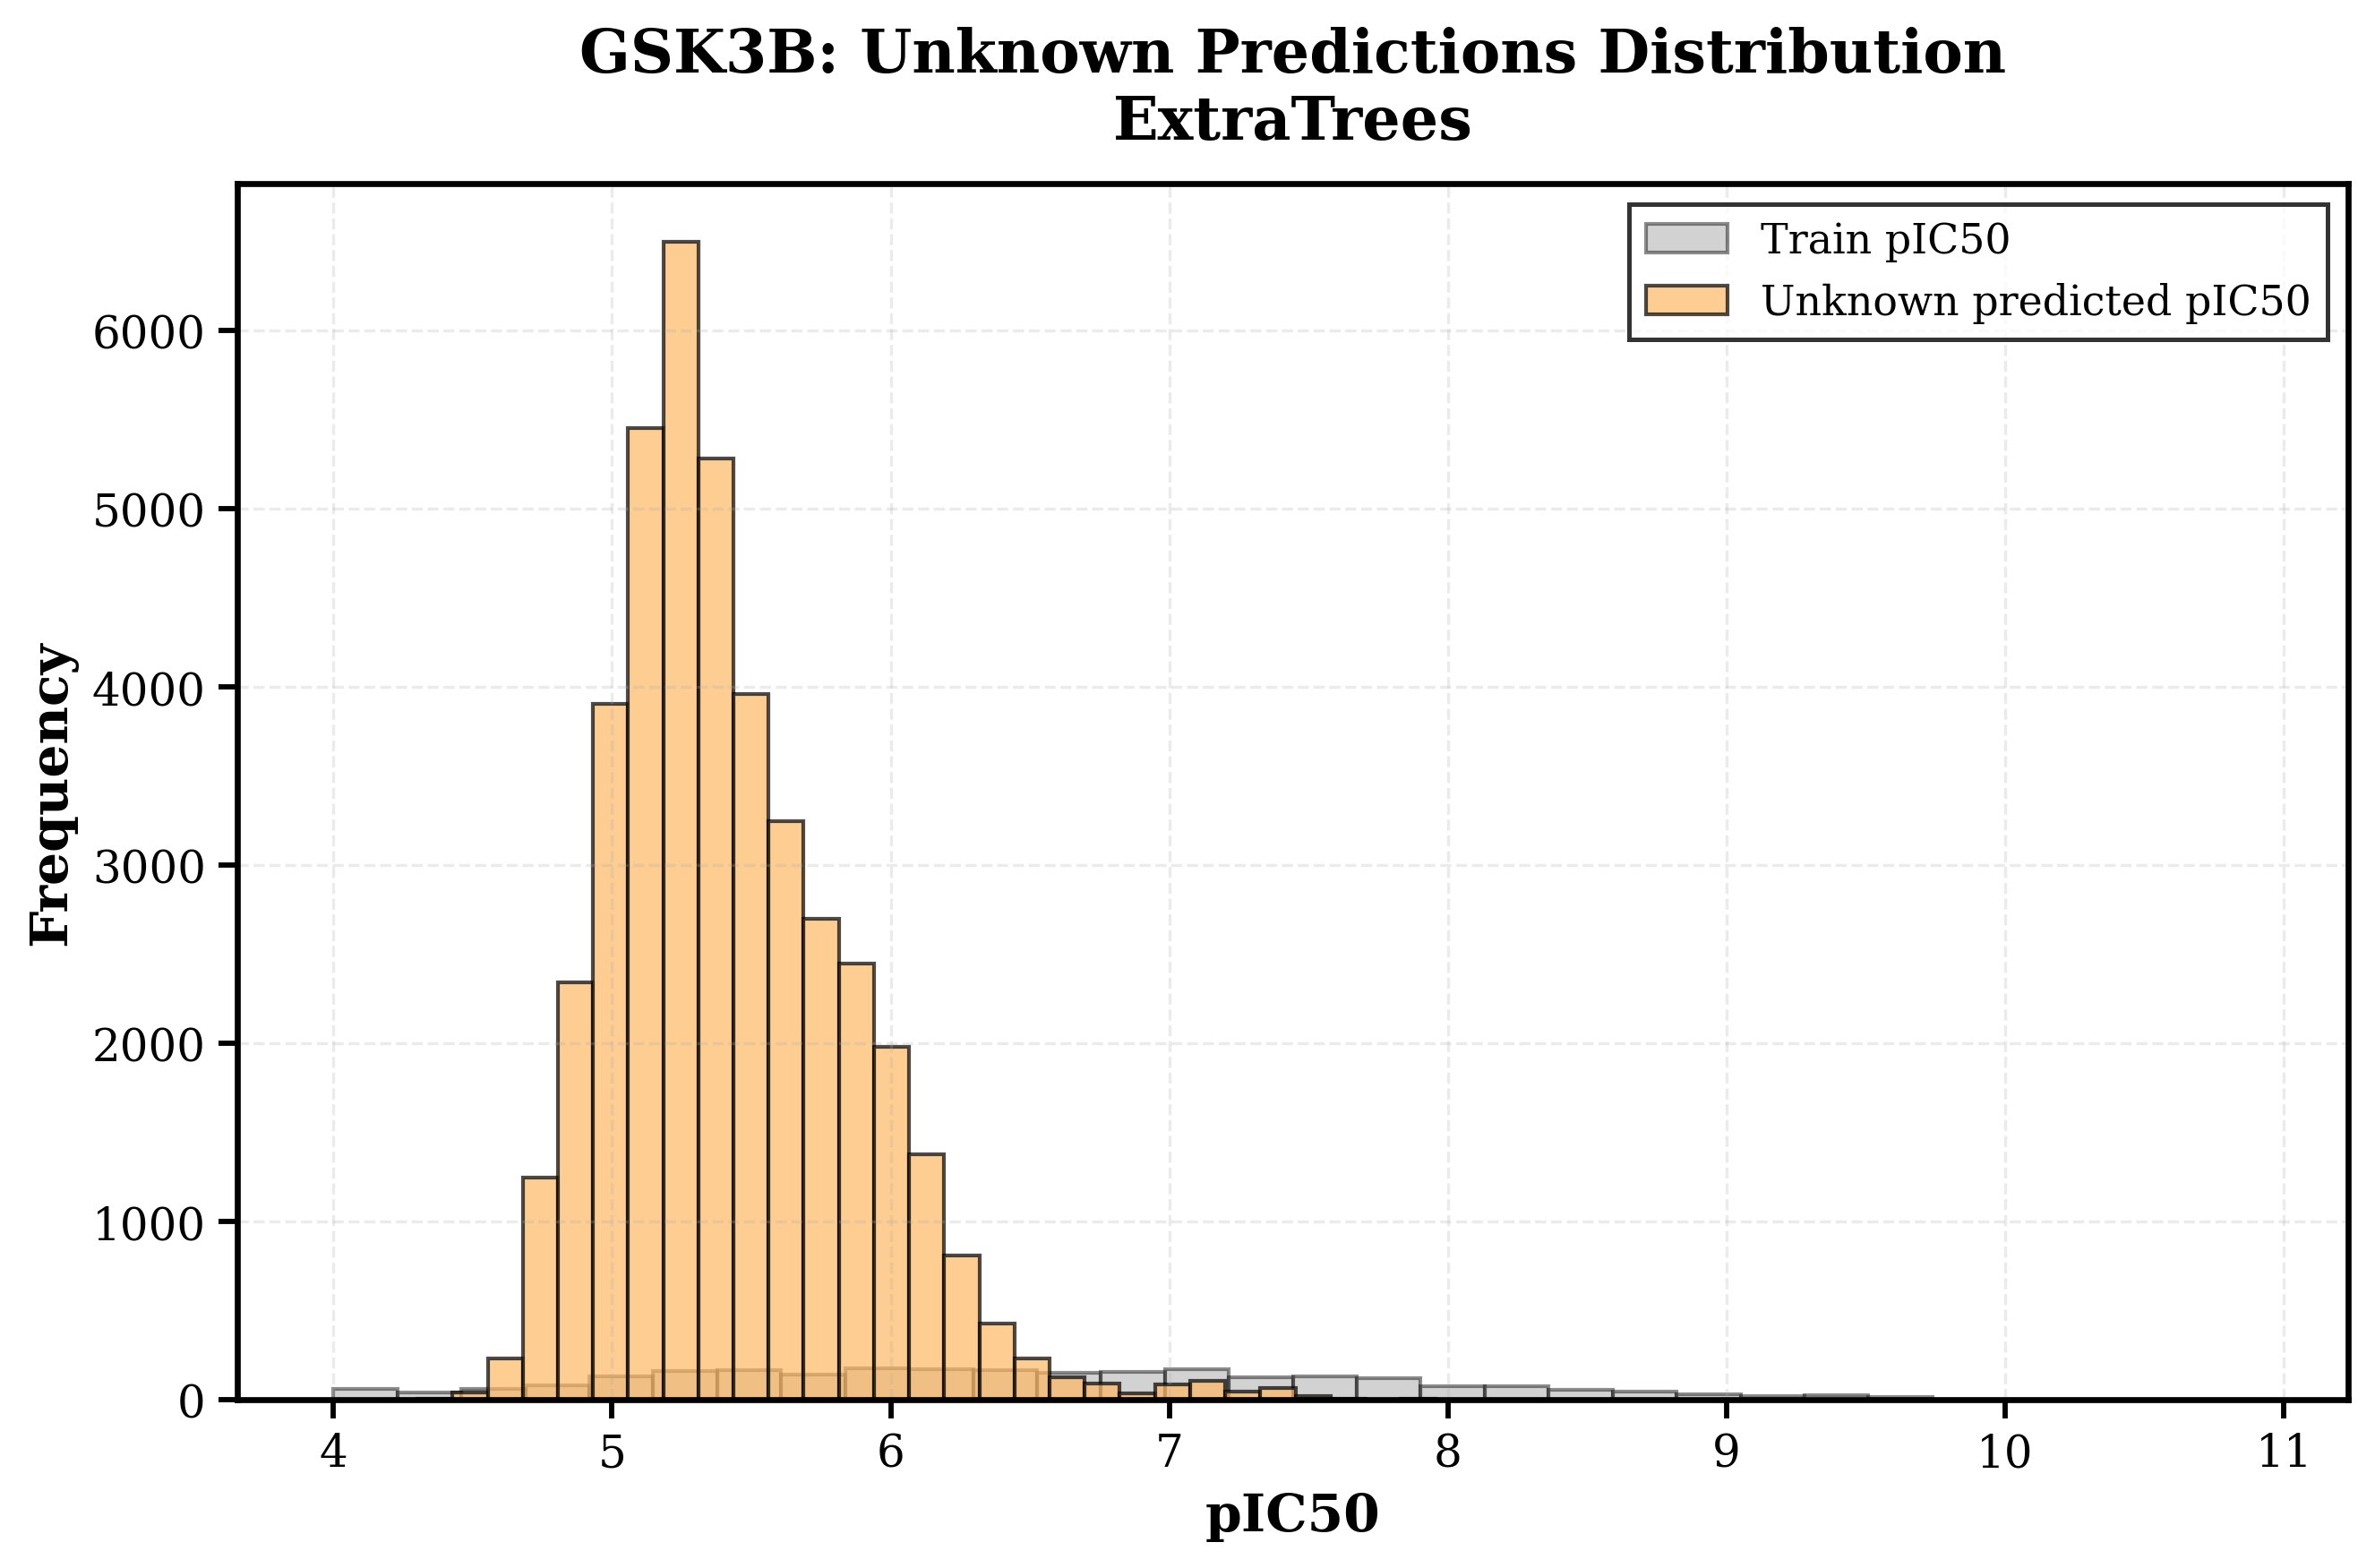

In [ ]:
# @title # PUB FIG: Unknown predicted pIC50 distribution (overlay training)
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(y_train, bins=30, alpha=0.45, color=COLORS["neutral"], edgecolor="black", linewidth=1.0, label="Train pIC50")
ax.hist(out["predicted_pIC50"].values, bins=30, alpha=0.70, color=COLORS["primary"], edgecolor="black", linewidth=1.0, label="Unknown predicted pIC50")
ax.set_xlabel("pIC50", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Unknown Predictions Distribution\n{best_model_name}", fontweight="bold", pad=12)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.8)
ax.legend(frameon=True, edgecolor="black", fontsize=11)
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_Fig10_UnknownPredicted_pIC50_Distribution", OUT_PLOTS)
plt.show()

In [ ]:
# @title # 20) SUMMARY REPORT (TXT)
# =========================
summary_text = f"""
{'='*80}
QSAR REGRESSION MODEL SUMMARY REPORT (PUBLICATION SAFE)
{'='*80}
Target: {OUTPUT_PREFIX}
Samples: {len(X):,}
Descriptors: {len(feature_cols):,}
Train/Test split: {len(X_train):,}/{len(X_test):,}  (stratified by pIC50 quantile bins)
Scaling: {SCALING} | Imputer: mean

BEST MODEL (selected by CV_RMSE ONLY): {best_model_name}
CV_RMSE (best): {results_df.loc[0,'CV_RMSE']:.4f}
CV_R2_mean:     {results_df.loc[0,'CV_R2_mean']:.4f}

OOF TRAIN PERFORMANCE (honest):
R²_OOF:   {r2_oof:.4f}
RMSE_OOF: {rmse_oof:.4f}
MAE_OOF:  {mae_oof:.4f}

TEST PERFORMANCE:
R²_test:   {r2_test:.4f}
Q²_test:   {q2_test_best:.4f}
CCC_test:  {ccc_test:.4f}
RMSE_test: {rmse_test:.4f}   (~{fold_error_from_pic50_err(rmse_test):.1f}× potency error)
MAE_test:  {mae_test:.4f}   (~{fold_error_from_pic50_err(mae_test):.1f}× potency error)

Error breakdown (Test):
|err| ≤ 0.5 pIC50: {err_le_05}/{len(y_test)} ({100*err_le_05/len(y_test):.1f}%)
|err| ≤ 1.0 pIC50: {err_le_10}/{len(y_test)} ({100*err_le_10/len(y_test):.1f}%)

Y-scrambling:
Enabled: {ENABLE_Y_SCRAMBLING}
Iterations: {Y_SCRAMBLE_ITERS if ENABLE_Y_SCRAMBLING else 0}
Scrambled R² mean±std: {np.mean(scrambled_r2) if scrambled_r2 else 0:.4f} ± {np.std(scrambled_r2) if scrambled_r2 else 0:.4f}

Applicability Domain for unknowns:
Enabled: {ENABLE_AD_UNKNOWN}
Method: PCA({AD_PCA_COMPONENTS}) + kNN(k={AD_KNN_K}), thr={AD_PERCENTILE_THR}th percentile (train mean distance)

Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""
print(summary_text)

summary_path = os.path.join(OUT_REPORT, f"{OUTPUT_PREFIX}_SUMMARY_REPORT.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)
print("✅ Saved report:", summary_path)


QSAR REGRESSION MODEL SUMMARY REPORT (PUBLICATION SAFE)
Target: GSK3B
Samples: 3,262
Descriptors: 2,265
Train/Test split: 2,609/653  (stratified by pIC50 quantile bins)
Scaling: standard | Imputer: mean

BEST MODEL (selected by CV_RMSE ONLY): ExtraTrees
CV_RMSE (best): 0.7422
CV_R2_mean:     0.6488

OOF TRAIN PERFORMANCE (honest):
R²_OOF:   0.6508
RMSE_OOF: 0.7430
MAE_OOF:  0.5443

TEST PERFORMANCE:
R²_test:   0.6795
Q²_test:   0.6795
CCC_test:  0.8120
RMSE_test: 0.7120   (~5.2× potency error)
MAE_test:  0.5144   (~3.3× potency error)

Error breakdown (Test):
|err| ≤ 0.5 pIC50: 406/653 (62.2%)
|err| ≤ 1.0 pIC50: 564/653 (86.4%)

Y-scrambling:
Enabled: True
Iterations: 25
Scrambled R² mean±std: -0.2592 ± 0.0510

Applicability Domain for unknowns:
Enabled: True
Method: PCA(30) + kNN(k=5), thr=95th percentile (train mean distance)

Date: 2026-05-31 01:56:14

✅ Saved report: /content/Regression_Prediction_GSK3B/REPORTS/GSK3B_SUMMARY_REPORT.txt


In [ ]:
# @title # 21) ZIP OUTPUTS + DOWNLOAD
# =========================
zip_path = f"/content/{OUTPUT_PREFIX}_PART3_3A_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files_in in os.walk(OUTROOT):
        for fn in files_in:
            full = os.path.join(root, fn)
            arc = os.path.relpath(full, os.path.dirname(OUTROOT))
            z.write(full, arcname=arc)

print(f"\n📦 Created ZIP: {zip_path}")
files.download(zip_path)
print("\n🎉 PART-3.3A COMPLETE!")



📦 Created ZIP: /content/GSK3B_PART3_3A_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 PART-3.3A COMPLETE!
